# **Pseudo code**

In [ ]:
#####################################################################
#                 FULL END-TO-END MODEL PIPELINE                    #
#####################################################################

# 1. pip instulls - U transformers, langdetect, evaluate, transformers[torch] accelerate datasets seqeval

# 2. imoprts

# 3. fine-tuning:

# 3.1.

# CONSTANTS:
#     MODEL_NAME = "ab-ai/pii_model"
#     SEED = 42
#     TEST_SIZE = 0.1
#     STRIDE = 128 // Overlap for long texts
#     MAX_LENGTH = 512

# // FUNCTION: check_file_consistency(file_path)

# IF file_path DOES NOT EXIST:
#     RETURN False (Error: File not found)

# post_count = 0
# is_consistent = True

# FOR each LINE in file:
#     IF LINE is NOT EMPTY:
#         // Check 1: Format Check
#         parts = SPLIT(LINE)
#         IF parts count IS NOT 2 (Token and Tag):
#             PRINT "Error: Incorrect number of parts on line"
#             is_consistent = False
#     ELSE (LINE is EMPTY):
#         // Check 2: Post Integrity Check
#         IF a previous post was collected:
#             post_count += 1
#             IF tokens count IS NOT EQUAL TO tags count:
#                 PRINT "Error: Mismatched token/tag count in post"
#                 is_consistent = False
#             CLEAR tokens and tags for new post

# // Final Check for the last post (if file doesn't end with blank line)
# IF tokens are still collected:
#     post_count += 1
#     IF tokens count IS NOT EQUAL TO tags count:
#         is_consistent = False

# RETURN is_consistent AND post_count

# 3.2.

# // DATA INGESTION AND MAPPING
# FUNCTION prepare_data(file_path):
#     // Load the raw fine-tuning file (token/tag pairs)
#     df = LOAD_FILE_TO_DATAFRAME(file_path)

#     // Map tags to numerical indices
#     (TAG_TO_ID, ID_TO_TAG) = CREATE_MAPPINGS_FROM_DF(df)

#     // Convert to Hugging Face Dataset format
#     dataset = CONVERT_DF_TO_DATASET(df)
#     dataset = MAP_TAGS_TO_INDICES(dataset, TAG_TO_ID)

#     RETURN dataset

# // MODEL PREPARATION AND DATA ALIGNMENT
# FUNCTION setup_and_align_data(dataset, model_name):
#     // Load Model and Tokenizer
#     (model, tokenizer) = LOAD_MODEL_AND_TOKENIZER(model_name)

#     // Tokenization and Label Alignment
#     // Breaks words into sub-tokens and aligns the tags accordingly.
#     tokenized_dataset = TOKENIZE_AND_ALIGN_LABELS(dataset, tokenizer)

#     // Split the data for training and evaluation
#     (train_set, eval_set) = SPLIT_DATASET(tokenized_dataset, test_size=0.1)

#     RETURN model, train_set, eval_set

# // MODEL EXECUTION AND EVALUATION
# FUNCTION run_training_and_evaluation(model, train_set, eval_set):
#     // Define training parameters and metrics (e.g., F1 score via seqeval)
#     (training_args, metrics_func) = DEFINE_TRAINING_CONFIGURATION()

#     // Initialize and run the Trainer
#     trainer = INITIALIZE_TRAINER(model, training_args, train_set, eval_set, metrics_func)
#     trainer.train()

#     // Saving the final model
#     SAVE_MODEL(trainer, "final_model_path")

# // EXECUTION FLOW
# dataset = prepare_data("fine_tuning_file.txt")
# (model, train_set, eval_set) = setup_and_align_data(dataset, "your_model_name")
# run_training_and_evaluation(model, train_set, eval_set)

# FUNCTION finalize_data_and_train(tokenized_datasets, model, training_args):

#     // Rebuild and Clean Dataset
#     rebuilt_data = []
#     FOR each example in tokenized_datasets:
#         // Extract only the fields required for the Trainer (Input IDs, Mask, Labels)
#         rebuilt_data.APPEND({input_ids, attention_mask, labels})

#     // Convert to new Dataset and Re-Split
#     rebuilt_dataset = CREATE_DATASET_FROM_LIST(rebuilt_data)

#     // Split the cleaned data into Train and Eval sets (for the final Trainer run)
#     (train_set, eval_set) = SPLIT_DATASET(rebuilt_dataset, test_size=0.1)

#     // Diagnostic Check (QA Step)
#     PRINT_DATASET_STRUCTURE_AND_DATATYPES(train_set)

#     // Training Execution
#     // Initialize Trainer with the *rebuilt* and *re-split* datasets
#     trainer = INITIALIZE_TRAINER(
#         model=model,
#         args=training_args,
#         train_dataset=train_set,
#         eval_dataset=eval_set,
#         // ... (data_collator, compute_metrics)
#     )

#     // Start Fine-Tuning
#     trainer.train()

#     // 6. Save Final Model
#     SAVE_MODEL(trainer, "./fine_tuned_pii_model_final")
#     SAVE_TOKENIZER(tokenizer, "./fine_tuned_pii_model_final")

# 4. MODEL AND PIPELINE SETUP

# // Set up the environment
# device = DETERMINE_DEVICE() // CUDA or CPU

# // Load components
# (tokenizer, model) = LOAD_MODEL_AND_TOKENIZER("ab-ai/pii_model")
# MOVE model TO device

# // Configure the ready-to-use PII detection tool
# pii_detector_pipeline = INITIALIZE_PIPELINE(model, tokenizer, stride=128)

# 5. Geting the Data

# // uploaded the data
# uploaded_file = files.upload()

# file_name = list(uploaded_file.keys())[0]

# // reading the data
# fb_df = pd.read_csv(file_name)

# 6. Preprocessing the data

# fb_df.drop(Irrelevant columns)

# fb_df[cols_to_fill].fillna(0)

# // Text preprocessing & normalizetion
# fb_df.dropna(subset=['text'])

# fb_df['text'].str.replace(Nulls, multiple spaces & blank rows)

# fb_df.drop_duplicates

# // remove non-english posts
# def detect_language(text):
#   fb_df['text'].apply(detect_language)
#   if "text" in fb_df is not "en":
#     drop
#   return fb_df

# fb_df['text'].drop(emoji_pattern)

# // creat average exposure_cols
# fb_df[exposure_cols].mean()

# 7. Model

# BATCH_SIZE = 256

# texts_to_process = fb_df["text"].tolist()

# pii_results = pii_detector_pipeline(
#     texts_to_process,
#     batch_size=BATCH_SIZE)

# # 8. PII RESULTS

# all_pii_data = COLLECT_PII_RESULTS(pii_results, fb_df.index)
#     pii_df = CONVERT_TO_DATAFRAME(all_pii_data)

# random_sample_df = SAMPLE_RANDOMLY(pii_df, n=30)
#     EXPORT_TO_CSV(random_sample_df, 'random_sample.csv') // Export random sample
#     EXPORT_TO_CSV(pii_df, 'all_pii_results.csv') // Export all results

# PRINT_STATISTICAL_SUMMARY(pii_df) // Total texts, total PII entities

In [ ]:
#####################################################################
#                 FULL END-TO-END  PIPELINE     V2                  #
#####################################################################

# Pipeline short review:

# 1. Install and import all the relevant libraries
# 2. Fine-tuning
# 3. Model and pipeline setup
# 4. Geting the Data
# 5. Preprocessing the data
# 6. Model
# 7. PII results

#####################################################################
#                             Train                                 #
#####################################################################

# Steps

# 1. Install and import all the relevant libraries

# 2. Fine-tuning:

# CONSTANTS:
#     MODEL_NAME = "ab-ai/pii_model"
#     SEED = 42
#     TEST_SIZE = 0.1
#     STRIDE = 128   # Overlap for long texts
#     MAX_LENGTH = 512

# Def check_file_consistency:
# This function validates the input file existence and format consistency.


# postcout = 0
# is_consistent = true


# for each line in file:
#     if line is not empty:
#         # Check 1: Format Check
#         parts = split(line)
#         if parts count is not 2 (Token and Tag):
#             print "Error: Incorrect number of parts on line"
#             is_consistent = False
#     else (line is empty):
#         # Check 2: Post Integrity Check
#         if a previous post was collected:
#             post_count += 1
#             if tokens count is not equal to tags count:
#                 print "Error: Mismatched token/tag count in post"
#                 is_consistent = False
#             clear tokens and tags for new post

# # Final Check for the last post (if file doesn't end with blank line)
# if tokens are still collected:
#     post_count += 1
#     if tokens count is not equal to tags count:
#         is_consistent = False

# return is_consistent and post_count

# # Data ingestion and mapping

# prepare_data(file_path):
#     # Load the raw fine-tuning file (token/tag pairs)
#     df = load_file_to_dataframe(file_path)

#     # Map tags to numerical indices
#     (tag_to_id, id_to_tag) = create_mappimg_from_df(df)


#     # Convert to Hugging Face Dataset format
#     dataset = convert_df_to_dataset(df)
#     dataset = map_tags_to_indices(dataset, TAG_TO_ID)

#     return dataset

# # Model preparation and data alignment
# setup_and_align_data(dataset, model_name):
#     # Load Model and Tokenizer
#     (model, TOLKENIZER) = load_model_and_tokenizer(MODEL_NAME)

#     # Tokenization and Label alignment
#     # Breaks words into sub-tokens and aligns the tags accordingly.
#     tokenized_dataset = tokenize_and_align_lables(dataset,  tokenizer)

#     # Split the data for training and evaluation
#     (train_set, eval_set) = split_dataset(tokenized_dataset, TEST_SIZE=0.1)

#     return model, train_set, eval_set

# # Model execution and evaluation
# run_training_and_evaluation(model, train_set, eval_set):
#     # Define training parameters and metrics (e.g., F1 score via seqeval)
#     (training_args, metrics_func) = define_traning_configuration

#     # Initialize and run the Trainer
#     trainer = initialize_trainer(model, training_args, train_set, eval_set, metrics_func)
#     trainer.train()

#     # Saving the final model
#     save_model(trainer, "final_model_path")

# # Execution flow
# dataset = prepare_data("fine_tuning_file.txt")
# (model, train_set, eval_set) = setup_and_align_data(dataset, "model_name")
# run_training_and_evaluation(model, train_set, eval_set)

# finalize_data_and_train(tokenized_datasets, model, training_args):

#     # Rebuild and clean dataset
#     rebuilt_data = []
#     for each example in tokenized_datasets:
#         # Extract only the fields required for the Trainer (Input IDs, mask, labels)
#         rebuilt_data.append({input_ids, attention_mask, labels})

#     # Convert to new dataset and re-split
#     rebuilt_dataset = creating_dataset_from_list(rebuilt_data)

#     # Split the cleaned data into train and eval sets (for the final Trainer run)
#     (train_set, eval_set) = split_dataset(rebuilt_dataset, TEST_SIZE = 0.1)

#     # Diagnostic check (QA Step)
#     print_dataset_dtructure_and_datatypes(train_set)

#     # Training execution
#     # Initialize trainer with the *rebuilt* and *re-split* datasets
#     trainer = initialize_trainer(
#         model=model,
#         args=training_args,
#         train_dataset=train_set,
#         eval_dataset=eval_set,
#         # ... (data_collator, compute_metrics)
#     )

#     # Start fine-tuning
#     trainer.train()

#     # Save final model
#     save_model(trainer, "./fine_tuned_pii_model_final")
#     save_tokenizer(tokenizer, "./fine_tuned_pii_model_final")


# 3. Model and pipeline setup

# # Set up the environment
# Device = determine_device # CUDA or CPU

# # Load components
# (tokenizer, model) = load_model_tokenizer("ab-ai/pii_model")
# move model to device

# # Configure the ready-to-use PII detection tool
# pii_detector_pipeline = initialize_pipline(model, tokenizer, STRIDE = 128)


# 4. Geting the Data

# Uploaded the data

# Rading the data

# 5. Preprocessing the data

# Remove irrelevant columns from the data

# Fill missing values ​​in numeric columns with 0

# # Text preprocessing & normalizetion
# Remove rows with an empty cell in the text column

# Clean Null characters (almost always noise)

# Remove duplicate rows

# # Remove non-english posts
# detect_language(text):
#   fb_df['text'].apply(detect_language)
#   if "text" in fb_df is not "en":
#     drop
#   return fb_df

# Remove emoji pattern

# # Creat average exposure_cols

# 6. Model

# BATCH_SIZE = 256

# Extract the column containing the raw texts from the input data frame and convert it into a list of sequences ready for processing

# Execute the pre-built PII detection pipeline on the prepared list of texts

# Store the complete output from the pipeline (pii_results)


#####################################################################
#                             Inference                             #
#####################################################################


# # 7. PII results

# all_pii_data = collect_pii_results(pii_results, fb_df.index)

# random_sample_df = sample_random(pii_df, n=30)


#####################################################################
#                               Notes                               #
#####################################################################

# 1. The fine-tuning ment to fix the labeling of the URL address as PII.
# 2. We use the usual matrixs to mesure the preference (Precision, Recall, F1 & Accuracy). the main matrix we try to maximized is F1.
# 3. We use 'stride' to cope with txet longer the the MAX_LENGTH (512) & to overlap between all the parts of the text in the cell.

 # **pip installs** ###

In [ ]:
!pip install geonamescache

In [ ]:
!pip install -U transformers

In [ ]:
!pip install langdetect

In [ ]:
 !pip install evaluate

In [ ]:
!pip install transformers[torch] accelerate datasets seqeval

In [ ]:
# pip install wandb

In [ ]:
!pip install scikit-posthocs

# **Longin to HuggingFace model**

In [ ]:
# from huggingface_hub import login
# login(new_session=False)
import os
from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

# **Imoprts**

In [ ]:
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline, TrainingArguments, Trainer
from google.colab import files
import pandas as pd
import concurrent.futures
import torch
import re
from scipy import stats
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException
from datasets import Dataset, ClassLabel, Sequence, Features, Value
import evaluate
from datasets import Dataset, ClassLabel, Sequence, Features, Value # Removed load_metric
from transformers import AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer
import numpy as np
# import wandb
import random
import math
import os
from langdetect import detect, DetectorFactory # Explicitly import DetectorFactory
from langdetect.lang_detect_exception import LangDetectException
# os.environ["WANDB_DISABLED"] = "true"
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForTokenClassification, TrainingArguments,
    Trainer, DataCollatorForTokenClassification
)
import evaluate
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression as lr
import statsmodels.api as sm
import statsmodels.formula.api as smf
# Gazetteer
import geonamescache
# TabStar
from importlib.resources import files
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from tabstar.tabstar_model import TabSTARClassifier
from pandas import DataFrame, Series
from tabstar.tabstar_model import TabSTARClassifier, TabSTARRegressor

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")

    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")
    print("Using CPU")

Using GPU: NVIDIA L4


# **Fine-Tuning**

In [ ]:
print(os.getcwd())
print(os.listdir("/content"))

/content
['.config', 'fine_tuning (3).txt', 'sample_data']


In [ ]:
def check_file_consistency(file_path):
    if not os.path.exists(file_path):
        print(f"Error: The file '{file_path}' does not exist.")
        return False, 0 # Modified to return False and 0 when file doesn't exist

    print(f"Checking file: '{file_path}' for consistency...")

    post_count = 0
    tokens = []
    tags = []
    is_consistent = True # Add a flag to track consistency

    with open(file_path, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()

            if line:
                parts = line.split()
                if len(parts) == 2:
                    tokens.append(parts[0])
                    tags.append(parts[1])
                else:
                    print(f"Inconsistency found on line {line_num}:")
                    print(f"  Expected 2 parts (token and tag), but found {len(parts)}.")
                    print(f"  Line content: '{line}'")
                    is_consistent = False # Set flag to False
                    # Continue processing to find all inconsistencies or return early?
                    # For now, let's find all inconsistencies.
            else:
                if tokens:
                    post_count += 1
                    if len(tokens) != len(tags):
                        print(f"Inconsistency found in post #{post_count}:")
                        print(f"  Mismatched number of tokens and tags.")
                        print(f"  Number of tokens: {len(tokens)}")
                        print(f"  Number of tags: {len(tags)}")
                        print(f"  Example Tokens: {tokens[:5]}...")
                        print(f"  Example Tags: {tags[:5]}...")
                        is_consistent = False # Set flag to False
                    tokens = []
                    tags = []

    # Check the last post if the file doesn't end with a blank line
    if tokens:
        post_count += 1
        if len(tokens) != len(tags):
            print(f"Inconsistency found in last post (#{post_count}):")
            print(f"  Mismatched number of tokens and tags.")
            print(f"  Number of tokens: {len(tokens)}")
            print(f"  Number of tags: {len(tags)}")
            is_consistent = False # Set flag to False

    if is_consistent:
        print("\nFile check passed. The file format is consistent.")
    else:
        print("\nInconsistencies found. Please correct the file.")

    return is_consistent, post_count # Return both consistency status and post count


# --- Running test ---
file_path = "/content/fine_tuning (3).txt"
is_consistent, post_count_result = check_file_consistency(file_path)

if is_consistent:
    print("You can now proceed with the fine-tuning code.")
    print(f"Total number of posts in the file: {post_count_result}")
else:
    print("\nPlease correct the inconsistencies in your file and try again.")

Checking file: '/content/fine_tuning (3).txt' for consistency...

File check passed. The file format is consistent.
You can now proceed with the fine-tuning code.
Total number of posts in the file: 7825


In [ ]:
# ------- 0) Constants -------
SEED = 42
TEST_SIZE = 0.1
STRIDE = 128  # Overlap between windows for long texts
# The default max_length (usually 512) can be used.
# To override the default: MAX_LEN = 512

def set_seed_all(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed_all(SEED)

# ------- 1) Louding the fine_tuning file  -------
file_path = 'fine_tuning (3).txt'

def load_data_from_file(file_path):
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        tokens, tags = [], []
        for line in f:
            line = line.strip()
            if line:
                parts = line.split()
                if len(parts) == 2:
                    tokens.append(parts[0])
                    tags.append(parts[1])
                # If a line doesn't match the format, simply ignore it (alternatively, warn/raise an Exception).
            else:
                if tokens:
                    data.append({'tokens': tokens, 'ner_tags': tags})
                tokens, tags = [], []
        if tokens:
            data.append({'tokens': tokens, 'ner_tags': tags})
    return data

df = pd.DataFrame(load_data_from_file(file_path))

# Actual list of tags from the data
label_list = sorted(list(set(tag for tags in df['ner_tags'] for tag in tags)))
tag_to_id = {tag: i for i, tag in enumerate(label_list)}
id_to_tag = {i: tag for i, tag in enumerate(label_list)}

# Building Dataset directly from DataFrame
dataset = Dataset.from_pandas(df)

# Mapping tags → indices
def map_tags_to_ids(examples):
    examples['ner_tags'] = [[tag_to_id.get(tag, -100) for tag in tags] for tags in examples['ner_tags']]
    return examples

dataset = dataset.map(map_tags_to_ids, batched=True)

# ------- 2) Loading Model and Tokenizer -------
model_name = "ab-ai/pii_model"
tokenizer = AutoTokenizer.from_pretrained(model_name)
num_labels = len(label_list)

model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=len(label_list),
    ignore_mismatched_sizes=True
)
# Convenient mappings for later use
model.config.label2id = tag_to_id
model.config.id2label = id_to_tag

# ------- 3) Tokenization + Label Alignment with STRIDE -------
def tokenize_and_align_labels_with_stride(examples, stride=STRIDE):
    all_input_ids, all_attention_masks, all_labels = [], [], []

    for tokens, labels in zip(examples["tokens"], examples["ner_tags"]):
        enc = tokenizer(
            tokens,
            is_split_into_words=True,
            truncation=True,
            # max_length=MAX_LEN,
            max_length=tokenizer.model_max_length,
            stride=stride,
            return_overflowing_tokens=True,
            return_offsets_mapping=False,
        )

        for i in range(len(enc["input_ids"])):
            word_ids = enc.word_ids(batch_index=i)
            label_ids = []
            prev_wid = None
            for wid in word_ids:
                if wid is None:
                    label_ids.append(-100)  # Special/Internal Padding Tokens
                else:
                    if wid != prev_wid:
                        label_ids.append(labels[wid])  # First sub-token of a word → Word's tag
                    else:
                        label_ids.append(-100)         # Subsequent sub-tokens → Ignored in loss
                prev_wid = wid

            all_input_ids.append(enc["input_ids"][i])
            all_attention_masks.append(enc["attention_mask"][i])
            all_labels.append(label_ids)

    return {
        "input_ids": all_input_ids,
        "attention_mask": all_attention_masks,
        "labels": all_labels,
    }

tokenized_datasets = dataset.map(
    lambda batch: tokenize_and_align_labels_with_stride(batch, stride=STRIDE),
    batched=True,
    remove_columns=['tokens', 'ner_tags']  # Removing original columns so the Trainer only receives required fields
)

# ------- 4) Splitting for fixed reproducibility -------
train_test_split = tokenized_datasets.train_test_split(test_size=TEST_SIZE, seed=SEED)
train_dataset = train_test_split['train']
eval_dataset  = train_test_split['test']

# ------- 5) Training Arguments (Fixes and Improvements) -------
training_args = TrainingArguments(
    output_dir="./fine_tuned_pii_model",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,   # Compare/Increase slightly; if VRAM is insufficient, revert to 2
    per_device_eval_batch_size=4,    #  Compare to the training set
    gradient_accumulation_steps=2,   #  Increasing effective batch size to 8 without additional VRAM (4*2)
    num_train_epochs=5,              # Can use 3–8; with load_best_model_at_end this is relatively safe
    weight_decay=0.01,
    save_strategy="epoch",
    save_total_limit=2,              #  Do not accumulate too many checkpoints
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_strategy="steps",        #  Logging frequency
    logging_steps=50,                #  Logging Frequency
    remove_unused_columns=False,     #  Keep False because columns were managed manually
    seed=SEED,                       #  Reproducibility
    report_to="none",                # Do not send to external loggers (optional)
    # fp16=True,                     # Optional, if a supporting GPU is available and stability is achieved
) # Added closing parenthesis here

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

# ------- 6)Metrics (seqeval) -------
metric = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_labels = [[label_list[l] for l in label if l != -100] for label in labels]
    true_predictions = [[label_list[pred] for (pred, lab) in zip(prediction, label) if lab != -100]
                        for prediction, label in zip(predictions, labels)]
    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall":    results["overall_recall"],
        "f1":        results["overall_f1"],
        "accuracy":  results["overall_accuracy"],
    }

# ------- 7) Initialize & Run Trainer -------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    # Removed the tokenizer argument as it's passed via data_collator
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

# ------- 8) Saving -------
trainer.save_model("./fine_tuned_pii_model_final")
tokenizer.save_pretrained("./fine_tuned_pii_model_final")

Map:   0%|          | 0/7825 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: ab-ai/pii_model
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([113, 768]) vs model:torch.Size([20, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([113]) vs model:torch.Size([20])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Map:   0%|          | 0/7825 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.027936,0.037233,0.657143,0.547619,0.597403,0.982860
2,0.017761,0.023688,0.805195,0.738095,0.770186,0.990091
3,0.004939,0.017804,0.813953,0.833333,0.823529,0.991966
4,0.015459,0.020643,0.829268,0.809524,0.819277,0.991966
5,0.001848,0.018833,0.853659,0.833333,0.843373,0.993573


...

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./fine_tuned_pii_model_final/tokenizer_config.json',
 './fine_tuned_pii_model_final/tokenizer.json')

In [ ]:
# Rebuilding the dataset with tokenized inputs and aligned labels

rebuilt_data = []
for i in range(len(tokenized_datasets)):
    example = tokenized_datasets[i]
    rebuilt_data.append({
        'input_ids': example['input_ids'],
        'attention_mask': example['attention_mask'],
        'labels': example['labels']
    })

# Create a new Dataset from the rebuilt data
rebuilt_dataset = Dataset.from_list(rebuilt_data)

# Split the rebuilt dataset into training and evaluation sets
rebuilt_train_test_split = rebuilt_dataset.train_test_split(test_size=0.1)
rebuilt_train_dataset = rebuilt_train_test_split['train']
rebuilt_eval_dataset = rebuilt_train_test_split['test']

print("Rebuilt dataset created and split into training and evaluation sets.")
print(f"Training dataset size: {len(rebuilt_train_dataset)}")
print(f"Evaluation dataset size: {len(rebuilt_eval_dataset)}")

# --- Diagnostic Step: Inspecting the rebuilt dataset ---
print("\n--- Inspecting Rebuilt Training Dataset ---")
print("Dataset structure:")
print(rebuilt_train_dataset)
print("\nFirst example from training dataset:")
print(rebuilt_train_dataset[0])
print("\nData types of the first example:")
for key, value in rebuilt_train_dataset[0].items():
    print(f"  {key}: Type is {type(value)}, first element type is {type(value[0]) if isinstance(value, list) else 'N/A'}")
    if isinstance(value, list):
        print(f"  {key} first 10 elements: {value[:10]}")

print("\n--- End of Inspection ---")
# --- End of Diagnostic Step ---


# Now, use the rebuilt datasets in the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=rebuilt_train_dataset,
    eval_dataset=rebuilt_eval_dataset,
#    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("\nStarting training with the rebuilt dataset...")
trainer.train()

# Save the fine-tuned model and tokenizer
trainer.save_model("./fine_tuned_pii_model_final")
tokenizer.save_pretrained("./fine_tuned_pii_model_final")

print("\nFine-tuning complete. Model and tokenizer saved.")

Rebuilt dataset created and split into training and evaluation sets.
Training dataset size: 7044
Evaluation dataset size: 783

--- Inspecting Rebuilt Training Dataset ---
Dataset structure:
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 7044
})

First example from training dataset:
{'input_ids': [101, 16770, 1024, 1013, 1013, 7479, 1012, 9130, 1012, 4012, 1013, 2686, 14821, 3527, 2094, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': [-100, 17, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100]}

Data types of the first example:
  input_ids: Type is <class 'list'>, first element type is <class 'int'>
  input_ids first 10 elements: [101, 16770, 1024, 1013, 1013, 7479, 1012, 9130, 1012, 4012]
  attention_mask: Type is <class 'list'>, first element type is <class 'int'>
  attention_mask first 10 elements: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  labels: Type is <class 'list'>, first element type 

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.002464,0.002777,0.918033,0.918033,0.918033,0.998805
2,0.012681,0.001030,0.951613,0.967213,0.959350,0.999522
3,0.000270,0.001238,0.951613,0.967213,0.959350,0.999522
4,0.008502,0.001151,0.951613,0.967213,0.959350,0.999522
5,0.000123,0.001175,0.951613,0.967213,0.959350,0.999522


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Fine-tuning complete. Model and tokenizer saved.


# **Define the model**


In [ ]:
# --- Model Definition ---
MODEL_NAME = "ab-ai/pii_model"
print(f"\nModel name set to: {MODEL_NAME}")


Model name set to: ab-ai/pii_model


In [ ]:
# --- Model Loading Configuration ---
MODEL_NAME = "ab-ai/pii_model"
print(f"\nModel name set to: {MODEL_NAME}")

# --- Set device for model (GPU or CPU) ---
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")
    print("Using CPU")

# --- Loading the tokenizer and model with specific parameters ---
print(f"Loading tokenizer from {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    max_length=512,
    truncation=True,
    # stride=128
)
print("Tokenizer loaded.")

print(f"Loading model from {MODEL_NAME}...")
model = AutoModelForTokenClassification.from_pretrained(MODEL_NAME)
print("Model loaded.")

print(f"Moving model to {device}...")
model.to(device)
print("Model moved to device.")

# --- Configuring PII detection pipeline ---
print("Configuring PII detection pipeline...")
pii_detector_pipeline = pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    stride=128
)
print("PII detection pipeline configured.")


Model name set to: ab-ai/pii_model
Using GPU: NVIDIA L4
Loading tokenizer from ab-ai/pii_model...
Tokenizer loaded.
Loading model from ab-ai/pii_model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded.
Moving model to cuda...
Model moved to device.
Configuring PII detection pipeline...
PII detection pipeline configured.


In [ ]:
print(f"Setting up PII detection pipeline on {device} with chunking support...")
pii_detector_pipeline = pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,

)
print("PII detection pipeline is ready and configured for long texts!")


Setting up PII detection pipeline on cuda with chunking support...
PII detection pipeline is ready and configured for long texts!


# **Geting the Data**


In [ ]:
import pandas as pd
from google.colab import files # Re-import files to ensure it's the correct module
import os # Ensure os is imported for path checks

print("\n--- Step 4.1: Uploading CSV File ---")
try:
    print("Please select your CSV file to upload:")
    # Note: files.upload() is interactive and will prompt the user in the UI.
    # In a non-interactive/automated environment, this will not work as expected.
    uploaded_file = files.upload()

    # Get the filename from the uploaded_file dictionary
    file_name = list(uploaded_file.keys())[0]
    print(f"File '{file_name}' uploaded successfully.")

    # Read the CSV file into a pandas DataFrame
    lin_df = pd.read_csv(file_name)
    print("\nCSV file loaded into DataFrame. You can now inspect it in the next cells.")

except Exception as e: # Corrected typo 'Exceprintption' to 'Exception'
    print(f"An error occurred during CSV upload: {e}") # Corrected print statement syntax
    # In case of an upload error, it's often best to stop here.
    # You might consider sys.exit() or just let the error propagate.



--- Step 4.1: Uploading CSV File ---
Please select your CSV file to upload:


Saving linkedin dataset.csv to linkedin dataset.csv
File 'linkedin dataset.csv' uploaded successfully.

CSV file loaded into DataFrame. You can now inspect it in the next cells.


# **Preprocessing the data**

In [ ]:
lin_df.sample(5)

,canPostComments,canReact,canShare,commentingDisabled,allowedCommentersScope,comments/0/text,isRepost,numLikes,numShares,reactions/1/type,...,comments/3/text,numComments,resharedPost/comments/0/text,resharedPost/comments/1/text,resharedPost/isRepost,resharedPost/numComments,resharedPost/numLikes,resharedPost/numShares,resharedPost/text,rootShare
12400,True,True,True,False,ALL,NaN,False,2.0,0.0,LIKE,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
20610,False,True,True,True,ALL,NaN,False,0.0,0.0,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
5394,True,True,True,False,ALL,Great opportunity,False,9.0,6.0,LIKE,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
26666,True,True,True,False,ALL,I'm interested,False,49.0,1.0,LIKE,...,I'm interested,76.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
6974,False,True,True,True,ALL,NaN,False,1.0,0.0,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True


In [ ]:
lin_df.shape

(27239, 26)

In [ ]:
lin_df.columns

Index(['canPostComments', 'canReact', 'canShare', 'commentingDisabled',
       'allowedCommentersScope', 'comments/0/text', 'isRepost', 'numLikes',
       'numShares', 'reactions/1/type', 'resharedPost/rootShare',
       'resharedPost/shareAudience', 'text', 'resharedPost/canPostComments',
       'resharedPost/type', 'comments/2/text', 'comments/3/text',
       'numComments', 'resharedPost/comments/0/text',
       'resharedPost/comments/1/text', 'resharedPost/isRepost',
       'resharedPost/numComments', 'resharedPost/numLikes',
       'resharedPost/numShares', 'resharedPost/text', 'rootShare'],
      dtype='object')

In [ ]:
# Removing unnecessary columns

lin_df.drop(columns=['canPostComments', 'canReact', 'canShare', 'commentingDisabled', 'allowedCommentersScope', 'comments/0/text',
                     'isRepost', 'reactions/1/type', 'comments/3/text', 'resharedPost/comments/0/text', 'resharedPost/comments/1/text',
                     'resharedPost/isRepost', 'resharedPost/text', 'resharedPost/canPostComments', 'resharedPost/shareAudience', 'resharedPost/type',
                     'comments/2/text', 'resharedPost/rootShare',
                     'rootShare'], inplace=True)

In [ ]:
lin_df.columns

Index(['numLikes', 'numShares', 'text', 'numComments',
       'resharedPost/numComments', 'resharedPost/numLikes',
       'resharedPost/numShares'],
      dtype='object')

In [ ]:
# Replace missing values in a numeric column with 0

cols_to_fill = ['numLikes', 'numShares', 'text',
       'numComments', 'resharedPost/numComments', 'resharedPost/numLikes',
       'resharedPost/numShares']

lin_df[cols_to_fill] = lin_df[cols_to_fill].fillna(0)

In [ ]:
lin_df.sample(5)

,numLikes,numShares,text,numComments,resharedPost/numComments,resharedPost/numLikes,resharedPost/numShares
18048,0.0,0.0,Role : PostgreSQL DBA\nLocation – : Remote \nD...,0.0,0.0,0.0,0.0
4091,2.0,0.0,Read carefully before calling!!!\n\nHey Linked...,1.0,0.0,0.0,0.0
9850,1.0,0.0,Role: Senior Business Analyst - Banking/Financ...,0.0,0.0,0.0,0.0
3070,3.0,0.0,"Morning All, I'm currently recruiting for a Ju...",0.0,0.0,0.0,0.0
22573,0.0,0.0,"Hi,\nHope you are doing great,\nI have urgent ...",0.0,0.0,0.0,0.0


In [ ]:
# Text preprocessing & normalizetion

# Removing rows contains NaN values
lin_df.dropna(subset=['text'], inplace=True)

# Converting dtype of text column from object to str
lin_df['text'] = lin_df['text'].astype(str)

# Clean Null characters (almost always noise)
lin_df['text'] = lin_df['text'].str.replace(r'[\x00]', '', regex=True)

# Normalize multiple spaces and remove spaces at the beginning/end of a string
lin_df['text'] = lin_df['text'].str.strip()
lin_df['text'] = lin_df['text'].str.replace(r'[\n\t]', ' ', regex=True)

initial_rows_after_cleaning = lin_df.shape
print(f"Number of rows before cleaning: {initial_rows_after_cleaning[0]}")

# Removing row that became blank after the previous stpes (like "str.srip command")
lin_df = lin_df[lin_df['text'].str.len() > 0]

# Removing duplicates
lin_df.drop_duplicates(inplace=True)

rows_after_empty_drop = lin_df.shape[0]
print(f"Number of rows after removing empty rows: {rows_after_empty_drop}")

Number of rows before cleaning: 27239
Number of rows after removing empty rows: 19421


In [ ]:
# To ensure consistent results across every run
DetectorFactory.seed = 0

def detect_language(text):
    """Identifies the language of a given text, handling empty texts or errors"""
    try:
        # If the text is empty or contains only whitespace, return None
        if pd.isna(text) or not str(text).strip():
            return None
        return detect(str(text))
    except LangDetectException:
        # If an identification error occurs (usually in very short texts), return 'unknown'
        return 'unknown'

# Check if fb_df is defined
if 'lin_df' in locals() and isinstance(lin_df, pd.DataFrame):
    print("Starting language detection. This might take a few moments...")

    # Applying the language detection function to the text column
    lin_df['detected_language'] = lin_df['text'].apply(detect_language)

    print("Language detection complete.")

    # Display the distribution of detected languages for an overview
    print("\nLanguage distribution:")
    print(lin_df['detected_language'].value_counts())

    # Filtering the DataFrame to keep only rows where the detected language is English ('en')
    lin_df = lin_df[lin_df['detected_language'] == 'en'].copy()

    # Display the number of rows after filtering
    print(f"\nNumber of rows after filtering for English: {lin_df.shape[0]}")

else:
    print("Error: 'lin_df' DataFrame not found. Please run the preceding cells to load and preprocess the data.")

Starting language detection. This might take a few moments...
Language detection complete.

Language distribution:
detected_language
en         18290
es           508
unknown      332
de            42
id            34
tl            30
pt            22
it            20
af            15
no            15
fr            14
ro            14
so            10
nl            10
ca             8
bn             7
sl             7
tr             6
hr             4
da             4
vi             4
fi             3
et             3
he             3
cy             2
cs             2
pl             2
te             2
hu             2
sw             1
sv             1
sq             1
lt             1
ar             1
el             1
Name: count, dtype: int64

Number of rows after filtering for English: 18290


In [ ]:
# Handling emojis

emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F1E0-\U0001F1FF"  # flags (iOS)
    "\U00002702-\U000027B0"
    "\U000024C2-\U0001F251"
    "\U0001f900-\U0001f9ff"  # supplemental symbols and pictographs
    "\U000025AA-\U000025FE"  # various geometric shapes
    "\U00002600-\U000026FF"  # misc symbols
    "\U0000FE0F"             # variation selectors
    "\U0001F004-\U0001F0CF"  # mahjong tiles, domino tiles
    "\U00002122-\U00003297"  # copyright, trademark etc.
    "\U000023F0-\U000023FF"  # alarm clocks, stopwatches
    "\U00002B50-\U00002B59"  # stars, circles, diamonds
    "\U00002934-\U00002935"  # arrows
    "]+", flags=re.UNICODE
)

lin_df['text'] = lin_df['text'].apply(lambda x: emoji_pattern.sub(r'', x))

In [ ]:
# cleaned_data_output_filename = 'lin_df_cleaned_preprocessed.csv'

# lin_df.to_csv(cleaned_data_output_filename, index=False, encoding='utf-8-sig')

In [ ]:
exposure_cols = [
    'numLikes', 'numShares', 'numComments', 'resharedPost/numComments',
    'resharedPost/numLikes', 'resharedPost/numShares'
]
# Calculate the Row-wise Mean
lin_df['exposure_score'] = lin_df[exposure_cols].mean(axis=1)

In [ ]:
# If before & after the "-" there are latters it's replace it with " " (space)
# Ment to inhance the detection of city names like: "Bnei-Brak", "Ramat-Gan"
lin_df['text_for_model'] = lin_df['text'].str.replace(r'(?<=[a-zA-Z])-(?=[a-zA-Z])', ' ', regex=True)

In [ ]:
# Checking whether the column types are correct

lin_df.sample(5)

,numLikes,numShares,text,numComments,resharedPost/numComments,resharedPost/numLikes,resharedPost/numShares,detected_language,exposure_score,text_for_model
2380,12.0,2.0,"Hi, We're looking for a Pay Per Click (PPC) ...",3.0,0.0,0.0,0.0,en,2.833333,"Hi, We're looking for a Pay Per Click (PPC) ..."
18032,0.0,0.0,Role : Sr. Snowflake Developer Location – : - ...,0.0,0.0,0.0,0.0,en,0.000000,Role : Sr. Snowflake Developer Location – : - ...
23353,3.0,0.0,We are Hiring for W2 Contract Role: Job Title ...,1.0,0.0,0.0,0.0,en,0.666667,We are Hiring for W2 Contract Role: Job Title ...
22948,1.0,1.0,We are hiring for #W2 Contract role 1- Job Ti...,0.0,0.0,0.0,0.0,en,0.333333,We are hiring for #W2 Contract role 1- Job Ti...
3513,42.0,0.0,We did it! First place secured in the EYouth ...,17.0,0.0,0.0,0.0,en,9.833333,We did it! First place secured in the EYouth ...


In [ ]:
lin_df.dtypes

,0
numLikes,float64
numShares,float64
text,object
numComments,float64
resharedPost/numComments,float64
resharedPost/numLikes,float64
resharedPost/numShares,float64
detected_language,object
exposure_score,float64
text_for_model,object


# **Bert Model**

In [ ]:
# # --- Running the model ---
# print("\n--- Step 5: Applying PII Detection Model ---")


# BATCH_SIZE = 256

# texts_to_process = lin_df["text"].tolist()
# print(f"Total texts to process: {len(texts_to_process)} entries.")

# print(f"Starting PII detection with batch size of {BATCH_SIZE}...")
# pii_results = pii_detector_pipeline(
#     texts_to_process,
#     batch_size=BATCH_SIZE,
# )
# print("PII detection complete for all texts!")

# ----------------------------------------

BATCH_SIZE = 256

# The model receives the customized text column (with spaces instead of dashes)
texts_to_process = lin_df["text_for_model"].tolist()
# Also preserves the original text column for searching emails in Regex
original_texts = lin_df["text"].tolist()

print(f"Total texts to process: {len(texts_to_process)} entries.")

print(f"Starting PII detection with batch size of {BATCH_SIZE}...")
pii_results = pii_detector_pipeline(
    texts_to_process,
    batch_size=BATCH_SIZE,
)
print("PII detection complete for all texts!")

Total texts to process: 18290 entries.
Starting PII detection with batch size of 256...
PII detection complete for all texts!


In [ ]:
# # --- Organizing and exporting the results to a DataFrame + random sampling ---
# print("\n--- Organizing and Exporting Results ---")

# all_pii_data = []

# # Create a list of original indices corresponding to the processed texts
# # This assumes the order of texts_to_process matches the order of the DataFrame after cleaning
# original_indices = lin_df.index.tolist()

# for i, results_for_text in enumerate(pii_results):
#     original_text_from_list = texts_to_process[i]
#     # Use the index from the original_indices list
#     original_df_index = original_indices[i]

#     if results_for_text:
#         for pii_item in results_for_text:
#             all_pii_data.append({
#                 'Original_DataFrame_Index': original_df_index,
#                 'Text_In_Processed_List_Index': i+2, # Index in the processed list (for debugging)
#                 'Original_Text': original_text_from_list,
#                 'PII_Entity': pii_item['word'],
#                 'PII_Type': pii_item['entity'],
#                 'Score': pii_item['score'],
#                 'Start_Char': pii_item['start'],
#                 'End_Char': pii_item['end'],
#                 'Is it right?': None
#             })
#     else:
#         # Include texts with no PII detected as well
#         all_pii_data.append({
#             'Original_DataFrame_Index': original_df_index,
#             'Text_In_Processed_List_Index': (i+2),
#             'Original_Text': original_text_from_list,
#             'PII_Entity': None,
#             'PII_Type': None,
#             'Score': None,
#             'Start_Char': None,
#             'End_Char': None
#         })


# pii_df = pd.DataFrame(all_pii_data)

# # --- Displaying examples in a table in Colab (random sampling) ---
# print("\n--- PII Detection Results (30 Random Sample Entries) ---")

# # Perform a random sample. If the DataFrame is smaller than 30, take all of them.
# num_random_samples = min(30, len(pii_df))
# if not pii_df.empty:
#     # sample(n=num_random_samples, random_state=42)`

#     random_sample_df = pii_df.sample(n=num_random_samples, random_state=42)


#     output_csv_filename_1 = 'random_sample_of_pii_results.csv'
#     random_sample_df.to_csv(output_csv_filename_1, index=False, encoding='utf-8-sig')
#     print(f"\nRandom sample results exported to '{output_csv_filename_1}'")
#     display(random_sample_df)

# # --- Export CSV ---
# output_csv_filename_2 = 'pii_detection_results_with_original_index.csv'
# pii_df.to_csv(output_csv_filename_2, index=False, encoding='utf-8-sig')
# print(f"\nAll results exported to '{output_csv_filename_2}'")

# # # --- Export to Excel (optional, requires openpyxl) ---
# # output_excel_filename = 'pii_detection_results_with_original_index.xlsx'
# # try:
# #     pii_df.to_excel(output_excel_filename, index=False)
# #     print(f"All results exported to '{output_excel_filename}' (Excel)")
# # except ImportError:
# #     print("\n'openpyxl' not installed. Skipping Excel export. Install with: !pip install openpyxl")

# print("\n--- Summary ---")
# total_texts_processed = len(texts_to_process)
# total_pii_entities_detected = pii_df['PII_Entity'].count()
# unique_texts_with_pii = pii_df[pii_df['PII_Entity'].notna()]['Original_DataFrame_Index'].nunique()
# print(f"Total number of original texts processed: {total_texts_processed}")
# print(f"Total number of PII entities detected across all texts: {total_pii_entities_detected}")
# print(f"Total number of unique original texts with at least one PII entity: {unique_texts_with_pii}")

## **Gazetteer**


In [ ]:
gc = geonamescache.GeonamesCache()

# Retrieving world cities (over 50,000 residents)
global_cities = gc.get_cities()
world_cities_en = [global_cities[c]['name'] for c in global_cities if global_cities[c]['population'] > 50000]

# Retrieving all countries in the world (English names only)
global_countries = gc.get_countries()
world_countries_en = [country['name'] for country in global_countries.values()]

# ג. List of cities in Israel (English names only)
israel_locations = [
    "Tel Aviv", "Jerusalem", "Haifa", "Rishon LeZion", "Petah Tikva", "Ashdod", "Netanya", "Beer Sheva",
    "Bnei Brak", "Holon", "Ramat Gan", "Rehovot", "Ashkelon", "Bat Yam", "Beit Shemesh", "Kfar Saba",
]

# Consolidating everything into one huge list & Removing duplicates
# We added world_countries_en here
combined_locations = list(set(world_cities_en + world_countries_en + israel_locations))

# Creating the Regex
# flags=re.IGNORECASE will make sure it catches both lowercase and uppercase letters
location_regex = r'\b(?:' + '|'.join(map(re.escape, combined_locations)) + r')\b'

print(f"Total locations in Gazetteer: {len(combined_locations)}")

Total locations in Gazetteer: 11527


## **Regex Detection**


In [ ]:
all_pii_data = []
original_indices = lin_df.index.tolist()

# Setting the template for emails
email_regex = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'

for i, results_for_text in enumerate(pii_results):
    orig_text = original_texts[i] # The original text (with hyphens and capital letters)
    original_df_index = original_indices[i]
    exposure_score = lin_df.loc[original_df_index, 'exposure_score']

    current_matches = []

    # A. If the model found something, we add it
    if results_for_text:
        for pii_item in results_for_text:
            current_matches.append({
                'Original_DataFrame_Index': original_df_index,
                'Original_Text': orig_text,
                'PII_Entity': pii_item['word'],
                'PII_Type': pii_item['entity'],
                'Score': pii_item['score'],
                'Source': 'Model',
                'Exposure_Score': exposure_score
            })

    # B. Regex search for emails in the original text (in case the model missed)
    regex_matches = re.finditer(email_regex, orig_text)
    for match in regex_matches:
        email_val = match.group()
        # We will only add if the model has not already recognized this email.
        if not any(email_val in str(m['PII_Entity']) for m in current_matches):
            current_matches.append({
                'Original_DataFrame_Index': original_df_index,
                'Original_Text': orig_text,
                'PII_Entity': email_val,
                'PII_Type': 'B-EMAIL',
                'Score': 1.0,
                'Source': 'Regex',
                'Exposure_Score': exposure_score
            })

    # C. Locations Gazetteer (new addition)
    city_matches = re.finditer(location_regex, orig_text, flags=re.IGNORECASE)
    for match in city_matches:
        city_val = match.group()

        # Duplicate prevention: Check if the model has already recognized this word (or part of it)
        is_already_found = any(city_val.lower() in str(m['PII_Entity']).lower() for m in current_matches)

        if not is_already_found:
            current_matches.append({
                'Original_DataFrame_Index': original_df_index,
                'Original_Text': orig_text,
                'PII_Entity': city_val,
                'PII_Type': 'B-LOC', # Cataloging as a location
                'Score': 1.0,         # Full certainty that this is on our list
                'Source': 'Gazetteer',
                'Exposure_Score': exposure_score
            })

    # C. If nothing is found (neither in the model nor in the Regex), we add an empty line.
    if not current_matches:
        all_pii_data.append({
            'Original_DataFrame_Index': original_df_index,
            'Original_Text': orig_text,
            'PII_Entity': None,
            'PII_Type': None,
            'Score': None,
            'Source': 'None',
            'Exposure_Score': exposure_score
        })
    else:
        all_pii_data.extend(current_matches)

pii_df = pd.DataFrame(all_pii_data)

# Clear the temporary column from the original data
lin_df.drop(columns=['text_for_model'], inplace=True)

In [ ]:
# --- Displaying examples in a table in Colab (random sampling) ---
print("\n--- PII Detection Results (30 Random Sample Entries) ---")

# Perform a random sample. If the DataFrame is smaller than 30, take all of them.
num_random_samples = min(30, len(pii_df))
if not pii_df.empty:
    # sample(n=num_random_samples, random_state=42)`

    random_sample_df = pii_df.sample(n=num_random_samples, random_state=42)


    output_csv_filename_1 = 'random_sample_of_pii_results.csv'
    random_sample_df.to_csv(output_csv_filename_1, index=False, encoding='utf-8-sig')
    print(f"\nRandom sample results exported to '{output_csv_filename_1}'")
    display(random_sample_df)

# --- Export CSV ---
output_csv_filename_2 = 'pii_detection_results_with_original_index.csv'
pii_df.to_csv(output_csv_filename_2, index=False, encoding='utf-8-sig')
print(f"\nAll results exported to '{output_csv_filename_2}'")

# # --- Export to Excel (optional, requires openpyxl) ---
# output_excel_filename = 'pii_detection_results_with_original_index.xlsx'
# try:
#     pii_df.to_excel(output_excel_filename, index=False)
#     print(f"All results exported to '{output_excel_filename}' (Excel)")
# except ImportError:
#     print("\n'openpyxl' not installed. Skipping Excel export. Install with: !pip install openpyxl")

print("\n--- Summary ---")
total_texts_processed = len(texts_to_process)
total_pii_entities_detected = pii_df['PII_Entity'].count()
unique_texts_with_pii = pii_df[pii_df['PII_Entity'].notna()]['Original_DataFrame_Index'].nunique()
print(f"Total number of original texts processed: {total_texts_processed}")
print(f"Total number of PII entities detected across all texts: {total_pii_entities_detected}")
print(f"Total number of unique original texts with at least one PII entity: {unique_texts_with_pii}")


--- PII Detection Results (30 Random Sample Entries) ---

Random sample results exported to 'random_sample_of_pii_results.csv'


,Original_DataFrame_Index,Original_Text,PII_Entity,PII_Type,Score,Source,Exposure_Score
13330,363,Unbreakable Mentality: Training Like You're Br...,##7,I-URL,0.991669,Model,0.000000
92899,5354,"We are hiring an Estimator for the Joliet, IL ...",75,B-AMOUNT,0.991614,Model,1.000000
346502,23256,We are Hiring for #W2 Contract role Title: #Ja...,suite,B-SECONDARYADDRESS,0.980576,Model,1.333333
53176,3019,I am currently looking for a Java Developer to...,mcgregor,I-EMAIL,0.803381,Model,1.166667
267695,19292,Job Role – MS SQL DBA + SAP Location – Remote ...,##85,I-SSN,0.592194,Model,0.000000
404180,26507,BlueWhale: The Future of Maritime Security ...,##x,I-URL,0.947903,Model,13.166667
276983,19534,Job Role – Network Data engineer Location – Fr...,/,I-URL,0.996553,Model,0.333333
71421,4037,"Hi Recruiters, I have a good consultants avail...",com,I-EMAIL,0.910372,Model,0.666667
337498,22997,We are Hiring for #W2 Contract role (Only US C...,|,I-ZIPCODE,0.857448,Model,1.000000
241980,18378,Role – UI Developer Location Taxes ( Multiple ...,com,I-EMAIL,0.720201,Model,0.000000



All results exported to 'pii_detection_results_with_original_index.csv'

--- Summary ---
Total number of original texts processed: 18290
Total number of PII entities detected across all texts: 416842
Total number of unique original texts with at least one PII entity: 17055


In [ ]:
# Chackig the full NER of PII for scesific row

example_index = 82
display(pii_df[pii_df['Original_DataFrame_Index'] == example_index])

,Original_DataFrame_Index,Original_Text,PII_Entity,PII_Type,Score,Source,Exposure_Score
1574,82,"In your fundraising appeal, the call to action...",bury,B-LOC,1.0,Gazetteer,0.833333
1575,82,"In your fundraising appeal, the call to action...",most,B-LOC,1.0,Gazetteer,0.833333


# =================================================================================

# **EDA**

In [ ]:
print(os.getcwd())
print(os.listdir("/content"))

/content
['.config', 'linkedin dataset.csv', 'pii_detection_results_with_original_index.csv', 'fine_tuned_pii_model_final', 'random_sample_of_pii_results.csv', 'fine_tuning (3).txt', 'fine_tuned_pii_model', 'sample_data']


In [ ]:
file_name_2 = 'pii_detection_results_with_regex_and_gazetteer.csv'
pii_df = pd.read_csv(file_name_2)
print(file_name_2)

FileNotFoundError: [Errno 2] No such file or directory: 'pii_detection_results_with_regex_and_gazetteer.csv'

In [ ]:
# inference_df
inf_df = pii_df.copy()

In [ ]:
  # Count posts with and without PII

# Define values to exclude when counting posts with PII (e.g., URLs that might not be considered sensitive in this context)
exclude_values = ['B-URL', 'I-URL']

# Posts with PII: Filter rows where 'PII_Entity' is not null AND 'PII_Type' is not in the exclude list,
# then count unique original post indices.
posts_with_pii_count = inf_df[
    inf_df['PII_Entity'].notna() & ~inf_df['PII_Type'].isin(exclude_values)
]['Original_DataFrame_Index'].nunique()


# Posts without PII: Filter rows where 'PII_Entity' is null and count unique original post indices
posts_without_pii_count = inf_df[inf_df['PII_Entity'].isnull()]['Original_DataFrame_Index'].nunique()

print(f"Number of unique posts with PII detected (excluding {exclude_values}): {posts_with_pii_count}")
print(f"Number of unique posts without PII detected: {posts_without_pii_count}")

# You can also verify the total matches the number of unique original posts
total_unique_posts = inf_df['Original_DataFrame_Index'].nunique()
print(f"Total number of unique original posts: {total_unique_posts}")

# Check if the sum matches the total (Considering that some posts might have only excluded PII types)
# A post could have only PII types from exclude_values. These posts will be counted in neither
# posts_with_pii_count nor posts_without_pii_count based on the current logic.
# Let's refine the check to account for this possibility.

# Count posts that contain *only* excluded PII types
posts_with_only_excluded_pii = inf_df[
    inf_df['PII_Entity'].notna() & inf_df['PII_Type'].isin(exclude_values)
]['Original_DataFrame_Index'].nunique()

# Now, the sum of the three categories should equal the total unique posts
calculated_total = posts_with_pii_count + posts_without_pii_count + posts_with_only_excluded_pii

if calculated_total == total_unique_posts:
    print("\nThe counts of posts with and without PII (and with only excluded PII) sum up to the total number of unique original posts.")
else:
    print("\nWarning: The sum of the counts does not match the total number of unique original posts. There might be an issue in the data or filtering.")
    print(f"Calculated Total: {calculated_total}")

Number of unique posts with PII detected (excluding ['B-URL', 'I-URL']): 16870
Number of unique posts without PII detected: 1235
Total number of unique original posts: 18290

Calculated Total: 21025


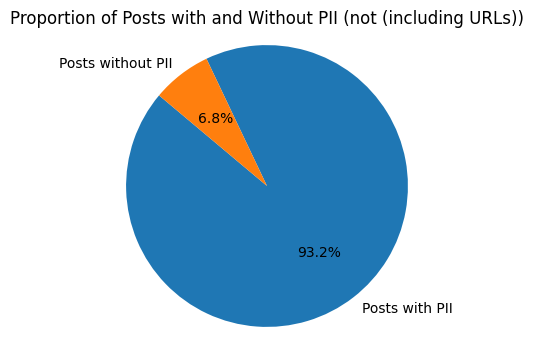

In [ ]:
# Create a list of counts and labels for the pie chart
counts = [posts_with_pii_count, posts_without_pii_count]
labels = ['Posts with PII', 'Posts without PII']

# Create the pie chart
plt.figure(figsize=(4, 4))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Proportion of Posts with and Without PII (not (including URLs))')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

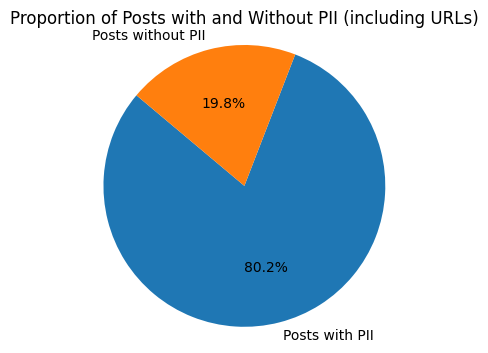

In [ ]:
# Create a list of counts and labels for the pie chart
counts = [posts_with_pii_count, posts_without_pii_count + posts_with_only_excluded_pii]
labels = ['Posts with PII', 'Posts without PII']

# Create the pie chart
plt.figure(figsize=(4, 4))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Proportion of Posts with and Without PII (including URLs)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
inf_df['PII_Type'].unique()
# hist()

array([None, 'B-AMOUNT', 'I-AMOUNT', 'B-FIRSTNAME', 'I-FIRSTNAME',
       'B-ACCOUNTNUMBER', 'I-ACCOUNTNUMBER', 'I-CURRENCYCODE',
       'B-CURRENCYCODE', 'B-CITY', 'I-STATE', 'B-STATE', 'I-CITY',
       'B-HEIGHT', 'I-HEIGHT', 'B-LOC', 'B-GENDER', 'I-GENDER',
       'B-JOBTYPE', 'I-JOBTYPE', 'I-URL', 'B-URL', 'B-LASTNAME',
       'I-LASTNAME', 'B-BIC', 'I-BIC', 'B-JOBAREA', 'I-STREET', 'B-EMAIL',
       'I-EMAIL', 'B-PHONENUMBER', 'I-PHONENUMBER', 'B-CURRENCY',
       'B-CREDITCARDISSUER', 'I-JOBAREA', 'I-CREDITCARDISSUER',
       'I-PREFIX', 'B-VEHICLEVRM', 'I-VEHICLEVRM', 'I-PASSWORD', 'B-AGE',
       'I-AGE', 'I-MIDDLENAME', 'B-COMPANYNAME', 'I-COMPANYNAME',
       'B-PASSWORD', 'B-MIDDLENAME', 'B-DOB', 'I-DOB', 'B-CURRENCYNAME',
       'I-CURRENCYNAME', 'B-COUNTY', 'I-COUNTY', 'I-USERNAME',
       'I-CURRENCY', 'B-STREET', 'B-USERNAME', 'B-DATE', 'I-DATE',
       'I-JOBTITLE', 'B-CURRENCYSYMBOL', 'I-BITCOINADDRESS', 'I-TIME',
       'B-TIME', 'B-ETHEREUMADDRESS', 'I-ETHEREUMADDRES

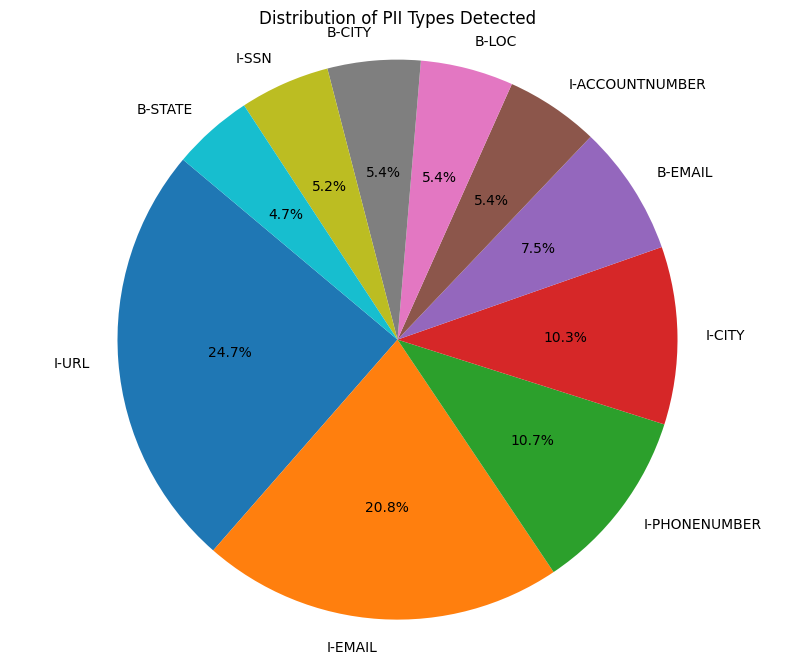

In [ ]:
# Filter out rows where 'PII_Type' is None
pii_types_df = inf_df.dropna(subset=['PII_Type'])

# Count the occurrences of each PII Type
pii_type_counts = pii_types_df['PII_Type'].value_counts().head(10) # Shows only the top 10 values count

# Create a pie chart
plt.figure(figsize=(10, 8))
plt.pie(pii_type_counts, labels=pii_type_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of PII Types Detected')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
# clean the subset data

posts_with_pii_count = inf_df.dropna(subset=['PII_Entity'])
posts_with_pii_count.sample(5)

,Original_DataFrame_Index,Original_Text,PII_Entity,PII_Type,Score,Source,Exposure_Score
395913,26116,If you’re looking for a results oriented emplo...,##3,I-URL,0.970854,Model,1.333333
199617,16980,"Dear Recruiters, I hope this message finds yo...",(,I-PHONENUMBER,0.615460,Model,0.333333
262425,19142,Job Title : Network Engineer ( Level 3 ) Locat...,##tek,I-EMAIL,0.997975,Model,0.000000
202449,17066,Title: Technical Writer 3 Location: Austin TX ...,##ness,I-LASTNAME,0.556037,Model,0.000000
362948,24499,What are the career OPTIONS as a 15 SERIES in ...,##d,I-URL,0.999375,Model,19.166667


In [ ]:
# Group the DataFrame by the original post index, PII type, and exposure score
# Then, count the number of occurrences for each combination.
# This helps in understanding how many times a specific PII type with a certain exposure score
# appeared in an original post

pii_count_df = posts_with_pii_count.groupby([
    'Original_DataFrame_Index',
    'PII_Type',
    'Exposure_Score'
]).size().reset_index(name='Count')

pii_count_df.head(10)

,Original_DataFrame_Index,PII_Type,Exposure_Score,Count
0,3,B-ACCOUNTNUMBER,427.5,1
1,3,B-AMOUNT,427.5,1
2,3,B-CITY,427.5,3
3,3,B-CURRENCYCODE,427.5,1
4,3,B-FIRSTNAME,427.5,2
5,3,B-HEIGHT,427.5,1
6,3,B-LOC,427.5,4
7,3,B-STATE,427.5,6
8,3,I-ACCOUNTNUMBER,427.5,5
9,3,I-AMOUNT,427.5,2


In [ ]:
# Most of the time if the count = 1 it's 'B-' that means it will count twice the same PII_Type
# I don't need the 'I-' for the counts of thr unique PII_Type
pii_count_df = pii_count_df[pii_count_df['PII_Type'].str.startswith('B')]
pii_count_df

,Original_DataFrame_Index,PII_Type,Exposure_Score,Count
0,3,B-ACCOUNTNUMBER,427.500000,1
1,3,B-AMOUNT,427.500000,1
2,3,B-CITY,427.500000,3
3,3,B-CURRENCYCODE,427.500000,1
4,3,B-FIRSTNAME,427.500000,2
...,...,...,...,...
141741,27237,B-JOBTITLE,0.833333,1
141742,27237,B-JOBTYPE,0.833333,1
141743,27237,B-LOC,0.833333,1
141747,27238,B-ACCOUNTNUMBER,1.166667,1


In [ ]:
# The purpose of the mapping is to distingush between 'hard' types of PII,
# those whose disclosure is a serious matter,
# to 'soft' PII that a person doesn't risk too much by exposing them.

pii_severity_map = {
    # Group 5: Critical and Direct Financial Risk
    'B-SSN': 5, 'B-CREDITCARDNUMBER': 5, 'B-PASSWORD': 5, 'B-IBAN': 5,
    'B-BITCOINADDRESS': 5, 'B-CREDITCARDCVV': 5, 'B-PIN': 5, 'B-ACCOUNTNUMBER': 5,
    'B-BIC': 5, 'B-ETHEREUMADDRESS': 5, 'B-LITECOINADDRESS': 5, 'B-ACCOUNTNAME': 5, # Group 5: 12 in total

    # Group 4: High Risk (Identity Theft)
    'B-DOB': 4, 'B-EMAIL': 4, 'B-PHONENUMBER': 4, 'B-FIRSTNAME': 4,
    'B-LASTNAME': 4, 'B-STREET': 4, 'B-BUILDINGNUMBER': 4,
    'B-ZIPCODE': 4, # Group 4: 8 in total

    # Group 3: Moderate Risk (Demographic and Device Identifiers)
    'B-AGE': 3, 'B-GENDER': 3, 'B-SEX': 3,
    'B-JOBAREA': 3, 'B-COMPANYNAME': 3, 'B-CITY': 3,
    'B-COUNTY': 3, 'B-IP': 3, 'B-MAC': 3, 'B-IPV4': 3,
    'B-IPV6': 3, 'B-USERAGENT': 3, 'B-PHONEIMEI': 3, 'B-VEHICLEVRM': 3,
    'B-VEHICLEVIN': 3, 'B-MIDDLENAME': 3,'B-SECONDARYADDRESS': 3, # Group 3: 17 in total

    # Group 2: Low Risk (Contextual and General Financial Details)
    'B-DATE': 2, 'B-TIME': 2,
    'B-CURRENCYNAME': 2,
    'B-CREDITCARDISSUER': 2, 'B-HEIGHT': 2, 'B-EYECOLOR': 2,
    'B-NEARBYGPSCOORDINATE': 2, 'B-USERNAME': 4, # Group 2: 8 in total

    # Group 1: Negligible Risk
    'B-MASKEDNUMBER': 0, 'B-PREFIX': 0, 'B-ORDINALDIRECTION': 0, 'B-STATE': 0,
    'B-CURRENCYCODE': 0, 'B-AMOUNT': 0, 'B-URL': 0, 'B-JOBTITLE': 0, 'B-JOBTYPE': 0,
    'B-CURRENCYSYMBOL': 0, 'B-CURRENCY': 2 # Group 1: 11 in total
}

In [ ]:
# Creating 'Severity_Score' column in the inf_df
pii_count_df['Severity_Score'] = pii_count_df['PII_Type'].map(pii_severity_map)
pii_count_df.head(5)

,Original_DataFrame_Index,PII_Type,Exposure_Score,Count,Severity_Score
0,3,B-ACCOUNTNUMBER,427.5,1,5.0
1,3,B-AMOUNT,427.5,1,0.0
2,3,B-CITY,427.5,3,3.0
3,3,B-CURRENCYCODE,427.5,1,0.0
4,3,B-FIRSTNAME,427.5,2,4.0


In [ ]:
# Group by 'Original_DataFrame_Index' and count the number of unique PII_Type values per post
# This creates a DataFrame with two columns: 'Original_DataFrame_Index' and 'Unique_PII_Count'
unique_pii_per_post = pii_count_df.groupby('Original_DataFrame_Index')['PII_Type'].nunique().reset_index(name='Unique_PII_Count')

# Merge the 'pii_count_df' (from earlier) with the 'unique_pii_per_post' DataFrame
# This adds the 'Unique_PII_Count' to each row in 'pii_count_df' based on the 'Original_DataFrame_Index'
merged_df_1 = pd.merge(pii_count_df, unique_pii_per_post, on='Original_DataFrame_Index', how='left')

# Group the 'merged_df_1' by 'Unique_PII_Count' and calculate the mean 'Exposure_Score' for each group
# This helps to see the average exposure score for posts with a certain number of unique PII types
average_exposure_by_pii_count = merged_df_1.groupby('Unique_PII_Count')['Exposure_Score'].mean().reset_index()

# Print the total number of rows in the merged DataFrame (for debugging/information)
print(len(merged_df_1))

# Display the first 5 rows of the merged DataFrame to inspect its structure and content
merged_df_1.head(5)

80974


,Original_DataFrame_Index,PII_Type,Exposure_Score,Count,Severity_Score,Unique_PII_Count
0,3,B-ACCOUNTNUMBER,427.5,1,5.0,8
1,3,B-AMOUNT,427.5,1,0.0,8
2,3,B-CITY,427.5,3,3.0,8
3,3,B-CURRENCYCODE,427.5,1,0.0,8
4,3,B-FIRSTNAME,427.5,2,4.0,8


In [ ]:
average_exposure_by_pii_count.head(5)

,Unique_PII_Count,Exposure_Score
0,1,50.853762
1,2,55.265086
2,3,91.395833
3,4,130.735262
4,5,17.934717


Average Exposure Score by Number of Unique PII Types:


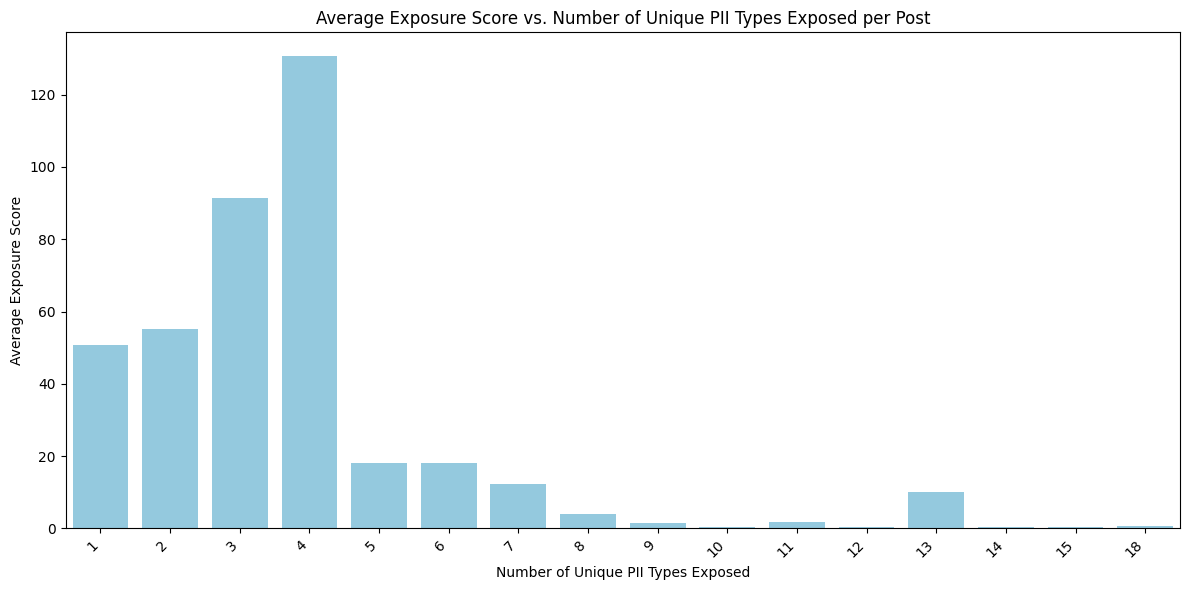

In [ ]:
print("Average Exposure Score by Number of Unique PII Types:")
# display(average_exposure_by_pii_count)

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Unique_PII_Count', y='Exposure_Score', data=average_exposure_by_pii_count, color='skyblue')
plt.xlabel('Number of Unique PII Types Exposed')
plt.ylabel('Average Exposure Score')
plt.title('Average Exposure Score vs. Number of Unique PII Types Exposed per Post')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

In [ ]:
# # Calculate the number of unique PII types per post again (needed for merging)
# unique_pii_per_post = pii_count_df.groupby('Original_DataFrame_Index')['PII_Type'].nunique().reset_index(name='Unique_PII_Count')

# # Merge the count of unique PII types per post with the pii_count_df
# # This adds the 'Unique_PII_Count' column to the pii_count_df
# merged_df_2 = pd.merge(pii_count_df, unique_pii_per_post, on='Original_DataFrame_Index', how='left')

# Group the merged DataFrame by the number of unique PII types
# Then, calculate the mean of both the 'Severity_Score' and 'Exposure_Score' for each group
average_exposure_by_pii_count = merged_df_1.groupby('Unique_PII_Count')[['Severity_Score', 'Exposure_Score']].mean().reset_index()

# Display the resulting DataFrame
average_exposure_by_pii_count

,Unique_PII_Count,Severity_Score,Exposure_Score
0,1,2.419643,50.853762
1,2,3.008652,55.265086
2,3,2.610996,91.395833
3,4,2.517517,130.735262
4,5,2.610995,17.934717
5,6,2.685250,18.179811
6,7,2.915855,12.205150
7,8,3.198735,3.859949
8,9,3.305577,1.441342
9,10,3.239814,0.444635


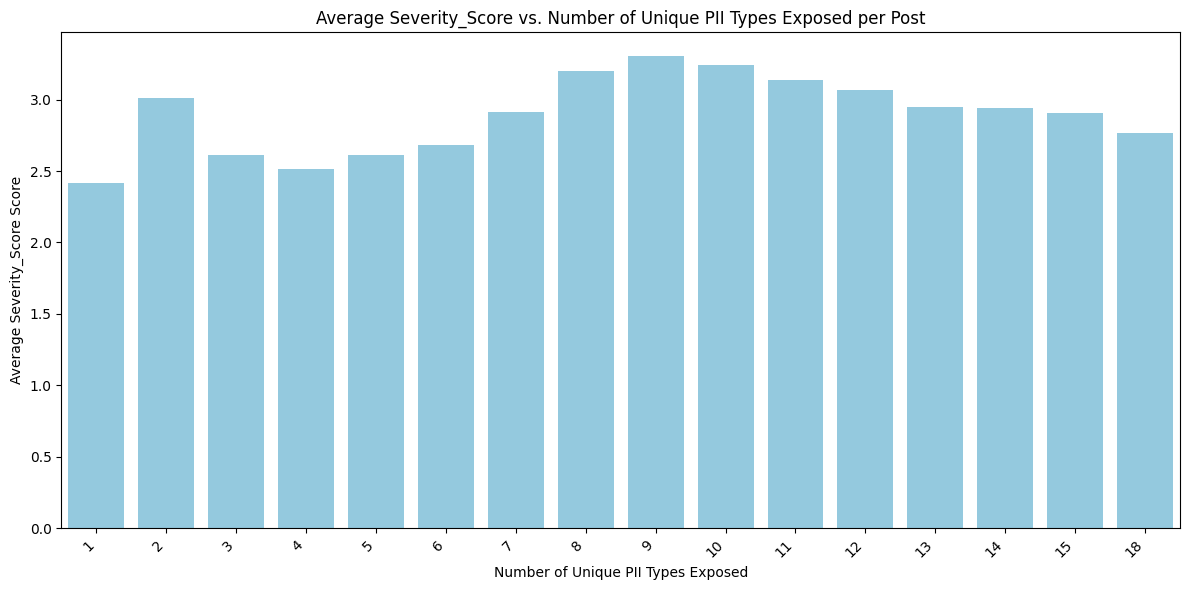

In [ ]:
# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Unique_PII_Count', y='Severity_Score', data=average_exposure_by_pii_count, color='skyblue')
plt.xlabel('Number of Unique PII Types Exposed')
plt.ylabel('Average Severity_Score Score')
plt.title('Average Severity_Score vs. Number of Unique PII Types Exposed per Post')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

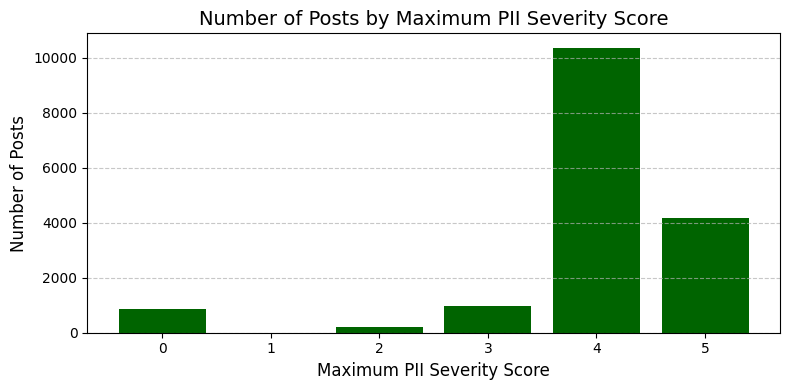

In [ ]:
severity_per_post = merged_df_1.groupby('Original_DataFrame_Index')[['Severity_Score', 'Exposure_Score']].max().reset_index()
severity_per_post

grouped_by_severity = severity_per_post.groupby('Severity_Score')['Original_DataFrame_Index'].count().reset_index()
grouped_by_severity

plt.figure(figsize=(8, 4))

plt.bar(
    grouped_by_severity['Severity_Score'], # X axis: Severity Score
    grouped_by_severity['Original_DataFrame_Index'], # Y axis: Count of Original DataFrame Index (Number of Posts)
    color='darkgreen'
)

plt.title('Number of Posts by Maximum PII Severity Score', fontsize=14)
plt.xlabel('Maximum PII Severity Score', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Correlation Matrix:


,Exposure_Score,Severity_Score
Exposure_Score,1.000000,-0.005661
Severity_Score,-0.005661,1.000000


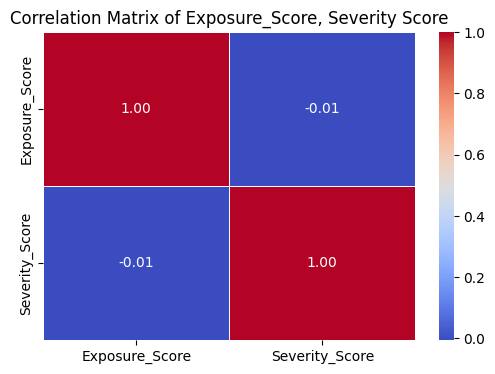

In [ ]:
### correlation pearson

# Select the relevant columns for correlation analysis
correlation_data = severity_per_post[['Exposure_Score', 'Severity_Score']]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Display the correlation matrix
print("Correlation Matrix:")
display(correlation_matrix)

# Optional: Visualize the correlation matrix as a heatmap for better readability
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Exposure_Score, Severity Score')
plt.show()

In [ ]:
unique_pii_per_post = pii_count_df.groupby('Original_DataFrame_Index')['PII_Type'].nunique().reset_index(name='Unique_PII_Count')
unique_pii_per_post
# merged_df = pd.merge(pii_count_df, unique_pii_per_post, on='Original_DataFrame_Index', how='left')

average_exposure_by_pii_count = merged_df_1.groupby('Unique_PII_Count')[['Severity_Score', 'Exposure_Score']].mean().reset_index()
average_exposure_by_pii_count

,Unique_PII_Count,Severity_Score,Exposure_Score
0,1,2.419643,50.853762
1,2,3.008652,55.265086
2,3,2.610996,91.395833
3,4,2.517517,130.735262
4,5,2.610995,17.934717
5,6,2.685250,18.179811
6,7,2.915855,12.205150
7,8,3.198735,3.859949
8,9,3.305577,1.441342
9,10,3.239814,0.444635


In [ ]:
unique_pii_per_post = pii_count_df.groupby('Original_DataFrame_Index')['PII_Type'].nunique().reset_index(name='Unique_PII_Count')

pii_count = unique_pii_per_post.groupby('Unique_PII_Count')['Original_DataFrame_Index'].count()
pii_count

,Original_DataFrame_Index
Unique_PII_Count,
1,1697
2,2994
3,2944
4,2454
5,1542
6,989
7,589
8,789
9,949


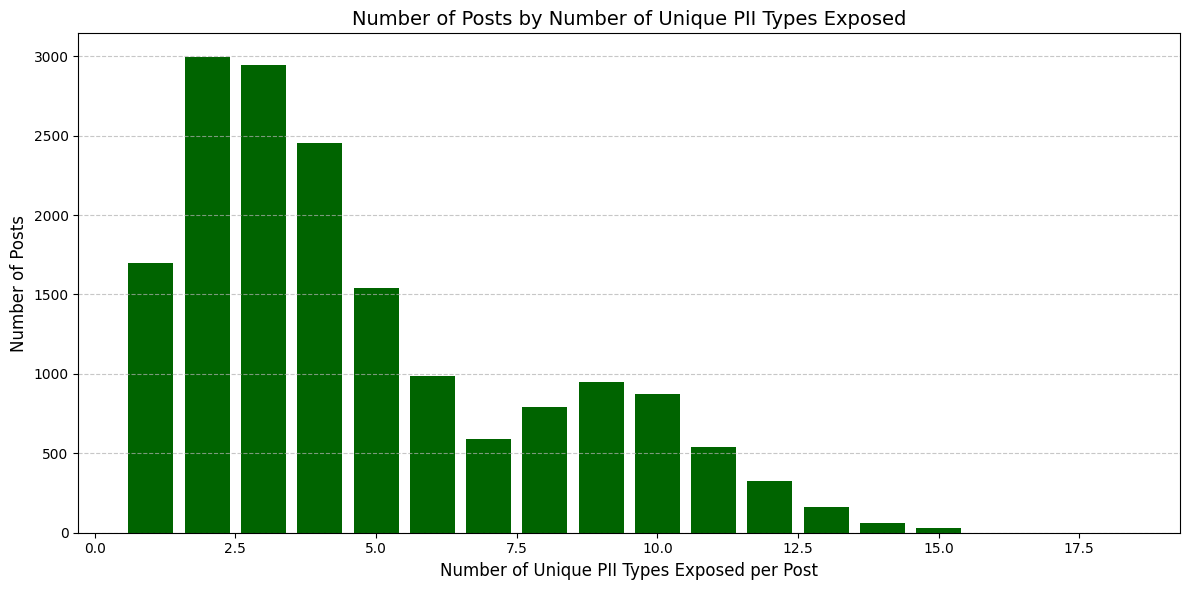

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    pii_count.index, # X axis: Number of Unique PII Types
    pii_count.values, # Y axis: Count of Original DataFrame Index (Number of Posts)
    color='darkgreen'
)

plt.title('Number of Posts by Number of Unique PII Types Exposed', fontsize=14)
plt.xlabel('Number of Unique PII Types Exposed per Post', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<Axes: xlabel='Unique_PII_Count', ylabel='Exposure_Score'>

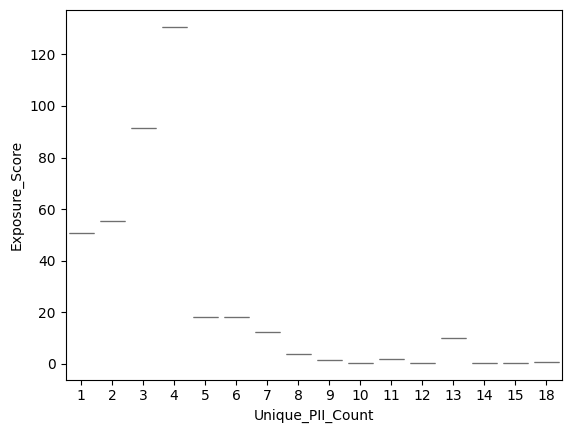

In [ ]:
sns.boxenplot(x='Unique_PII_Count', y='Exposure_Score', data=average_exposure_by_pii_count, color='skyblue')

/tmp/ipython-input-2324582394.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


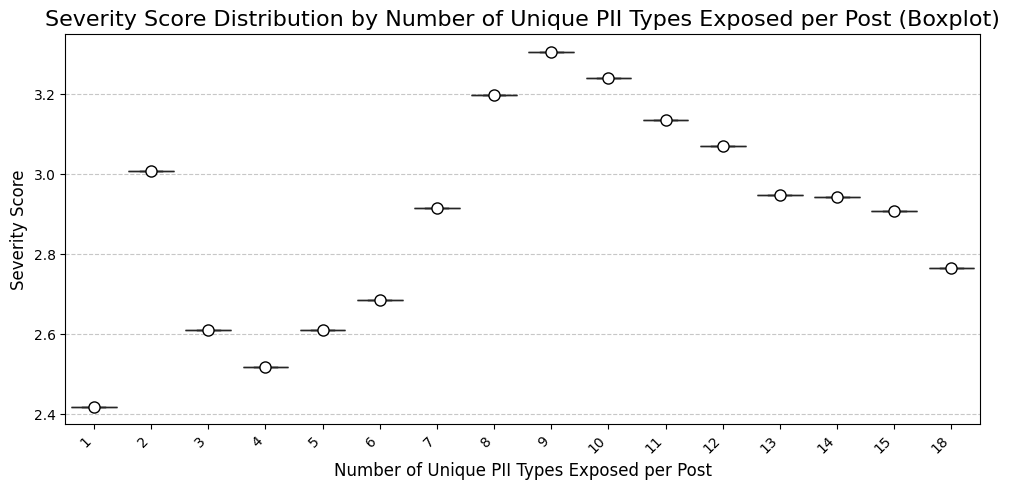

In [ ]:
plt.figure(figsize=(10, 5)) # Increase figure size for better readability
sns.boxplot(
    x='Unique_PII_Count',
    y='Severity_Score',
    data=average_exposure_by_pii_count,  # Use the merged_df which contains individual data points
    palette='viridis', # Use a different color palette
    linewidth=1, # Add some linewidth to the boxes
    showmeans=True,  # Show the mean
    meanprops={"marker":"o",  # Style the mean marker
               "markerfacecolor":"white",
               "markeredgecolor":"black",
               "markersize":"8"}
)
plt.title('Severity Score Distribution by Number of Unique PII Types Exposed per Post (Boxplot)', fontsize=16) # Improve title
plt.xlabel('Number of Unique PII Types Exposed per Post', fontsize=12)
plt.ylabel('Severity Score', fontsize=12)
plt.xticks(rotation=45, ha='right') # Keep rotation for readability
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add grid for better readability
plt.tight_layout() # Adjust layout
plt.show()

### Exposure Score & Severity Score correlation

Correlation Matrix:


,Exposure_Score,Severity_Score,Unique_PII_Count
Exposure_Score,1.000000,-0.001244,-0.017122
Severity_Score,-0.001244,1.000000,0.119958
Unique_PII_Count,-0.017122,0.119958,1.000000


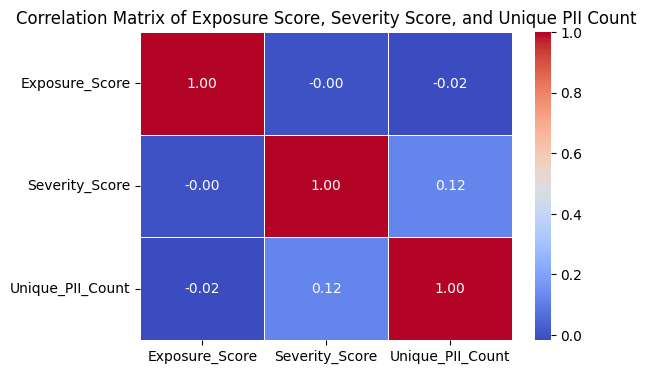

In [ ]:
### correlation pearson

# Select the relevant columns for correlation analysis
correlation_data = merged_df_1[['Exposure_Score', 'Severity_Score', 'Unique_PII_Count']]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Display the correlation matrix
print("Correlation Matrix:")
display(correlation_matrix)

# Optional: Visualize the correlation matrix as a heatmap for better readability
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Exposure Score, Severity Score, and Unique PII Count')
plt.show()

Correlation Matrix:


,Exposure_Score,Severity_Score,Unique_PII_Count
Exposure_Score,1.000000,-0.633679,-0.675941
Severity_Score,-0.633679,1.000000,0.434555
Unique_PII_Count,-0.675941,0.434555,1.000000


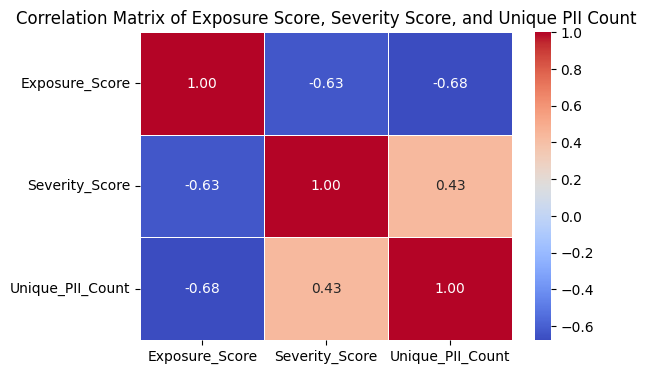

In [ ]:
### correlation pearson

# Select the relevant columns for correlation analysis
correlation_data = average_exposure_by_pii_count[['Exposure_Score', 'Severity_Score', 'Unique_PII_Count']]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Display the correlation matrix
print("Correlation Matrix:")
display(correlation_matrix)

# Optional: Visualize the correlation matrix as a heatmap for better readability
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Exposure Score, Severity Score, and Unique PII Count')
plt.show()

Correlation Matrix:


,Exposure_Score,Severity_Score,Original_DataFrame_Index
Exposure_Score,1.000000,-0.001244,0.000443
Severity_Score,-0.001244,1.000000,0.089683
Original_DataFrame_Index,0.000443,0.089683,1.000000


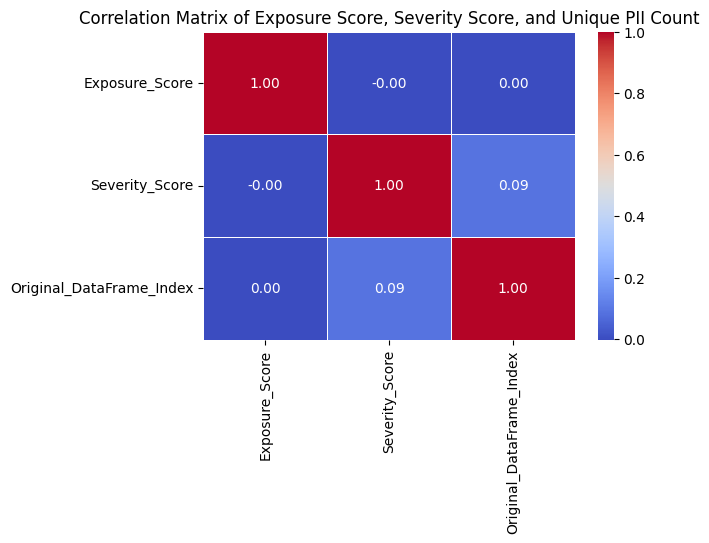

In [ ]:
### correlation pearson

# Select the relevant columns for correlation analysis
correlation_data = pii_count_df[['Exposure_Score', 'Severity_Score', 'Original_DataFrame_Index']]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Display the correlation matrix
print("Correlation Matrix:")
display(correlation_matrix)

# Optional: Visualize the correlation matrix as a heatmap for better readability
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Exposure Score, Severity Score, and Unique PII Count')
plt.show()

Spearman Correlation Matrix:


,Exposure_Score,Severity_Score,Unique_PII_Count
Exposure_Score,1.000000,-0.115104,-0.452927
Severity_Score,-0.115104,1.000000,0.121959
Unique_PII_Count,-0.452927,0.121959,1.000000


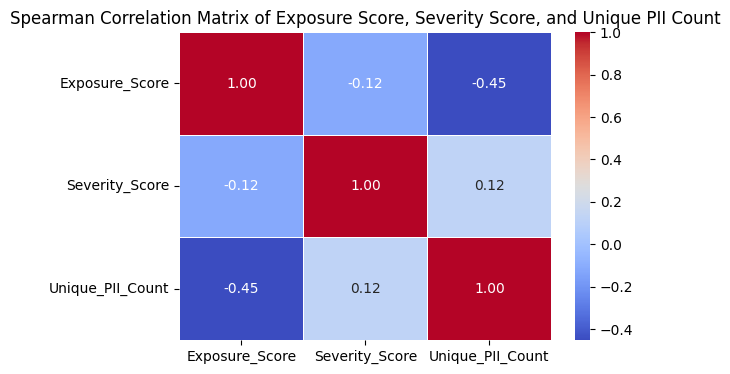

In [ ]:
### spearman correlation

# Select the relevant columns for correlation analysis
correlation_data = merged_df_1[['Exposure_Score', 'Severity_Score', 'Unique_PII_Count']]

# Calculate the correlation matrix using the Spearman method
correlation_matrix = correlation_data.corr(method='spearman')

# Display the correlation matrix
print("Spearman Correlation Matrix:")
display(correlation_matrix)

# Optional: Visualize the correlation matrix as a heatmap for better readability
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Spearman Correlation Matrix of Exposure Score, Severity Score, and Unique PII Count')
plt.show()

### Linear Regression Test

In [ ]:
from sklearn.linear_model import LinearRegression as lr

X = merged_df_1[['Unique_PII_Count']]
Y = merged_df_1[['Exposure_Score']]

model = lr() # Use a different variable name for the model instance
model.fit(X,Y)

print(model.coef_[0])
print(model.intercept_)
print("R^2:", model.score(X, Y)) # Add back the R^2 score calculation

[-9.61671577]
[101.56814695]
R^2: 0.00029317115007987393


In [ ]:
X = merged_df_1[['Unique_PII_Count']]
Y = merged_df_1[['Exposure_Score']]

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

# Results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         Exposure_Score   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     23.75
Date:                Sat, 07 Feb 2026   Prob (F-statistic):           1.10e-06
Time:                        21:33:37   Log-Likelihood:            -7.2666e+05
No. Observations:               80974   AIC:                         1.453e+06
Df Residuals:                   80972   BIC:                         1.453e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              101.5681     15.121  

In [ ]:
merged_df_1.drop(columns=['Count'], inplace=True)

In [ ]:
merged_df_1.head(5)

,Original_DataFrame_Index,PII_Type,Exposure_Score,Severity_Score,Unique_PII_Count
0,3,B-ACCOUNTNUMBER,427.5,5.0,8
1,3,B-AMOUNT,427.5,0.0,8
2,3,B-CITY,427.5,3.0,8
3,3,B-CURRENCYCODE,427.5,0.0,8
4,3,B-FIRSTNAME,427.5,4.0,8


In [ ]:
# exposure & severity
s_an_e_per_post = merged_df_1.groupby('Original_DataFrame_Index')[['Exposure_Score', 'Severity_Score', 'Unique_PII_Count']].max().reset_index()
s_an_e_per_post

,Original_DataFrame_Index,Exposure_Score,Severity_Score,Unique_PII_Count
0,3,427.500000,5.0,8
1,4,196.500000,5.0,8
2,5,9.500000,0.0,3
3,7,164.333333,5.0,7
4,9,357.666667,5.0,7
...,...,...,...,...
16936,27234,1.666667,0.0,1
16937,27235,1.000000,2.0,1
16938,27236,1.666667,4.0,5
16939,27237,0.833333,4.0,5


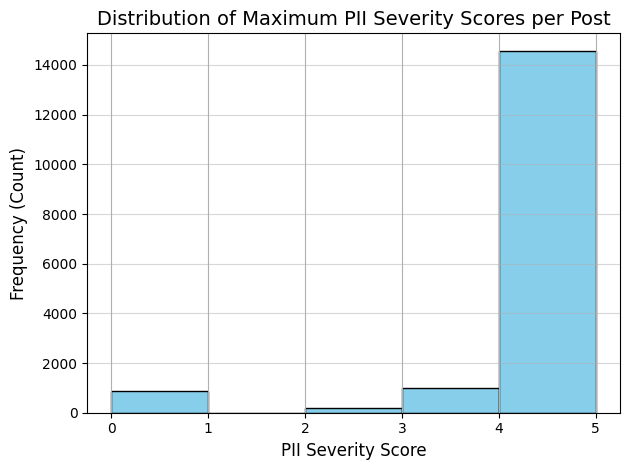

In [ ]:
s_an_e_per_post['Severity_Score'].hist(
    bins=5, # Adjusted number of bins for better visualization of severity scores (0-5)
    edgecolor='black',
    color='skyblue' # Added color
)
plt.title('Distribution of Maximum PII Severity Scores per Post', fontsize=14) # Changed title to English and made it more descriptive
plt.xlabel('PII Severity Score', fontsize=12) # Changed label to English
plt.ylabel('Frequency (Count)', fontsize=12) # Changed label to English and clarified

plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipython-input-3723148588.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_pii_counts.index, y=unique_pii_counts.values, palette='viridis')


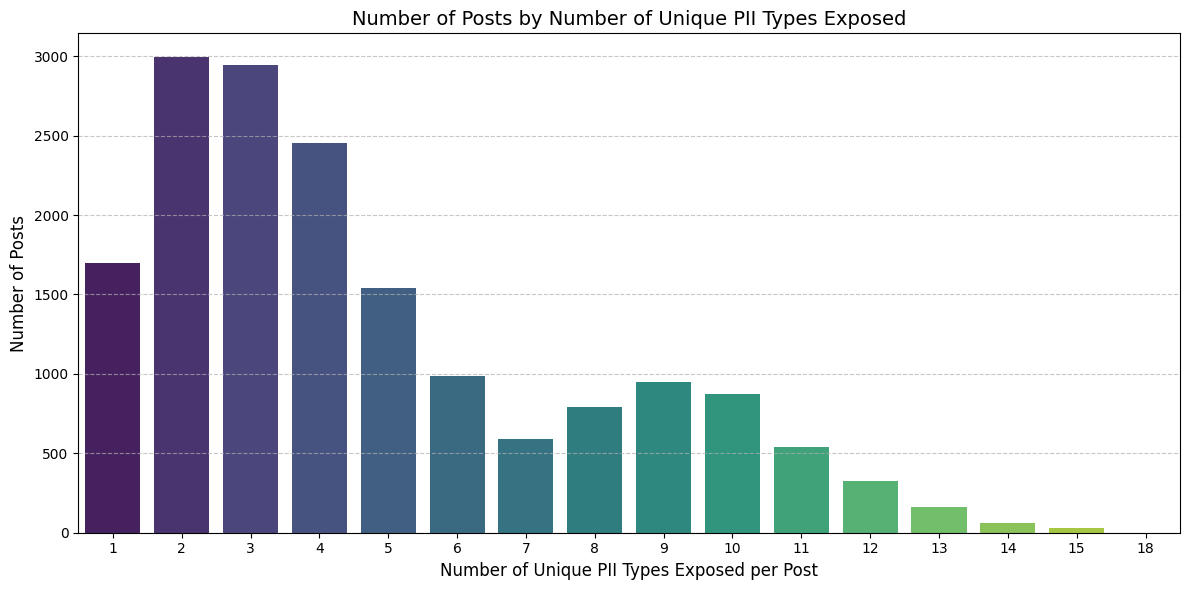

In [ ]:
# Count the occurrences of each Unique_PII_Count
unique_pii_counts = s_an_e_per_post['Unique_PII_Count'].value_counts().sort_index()

# Create a bar plot for the distribution of Unique_PII_Count
plt.figure(figsize=(12, 6))
sns.barplot(x=unique_pii_counts.index, y=unique_pii_counts.values, palette='viridis')

plt.title('Number of Posts by Number of Unique PII Types Exposed', fontsize=14)
plt.xlabel('Number of Unique PII Types Exposed per Post', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# count of posts for any Severity Scores

cout_post_per_severity = s_an_e_per_post['Severity_Score'].value_counts().sort_index()
cout_post_per_severity

,count
Severity_Score,
0.0,863
2.0,194
3.0,985
4.0,10370
5.0,4176


 ### Normality test By QQ-Plot

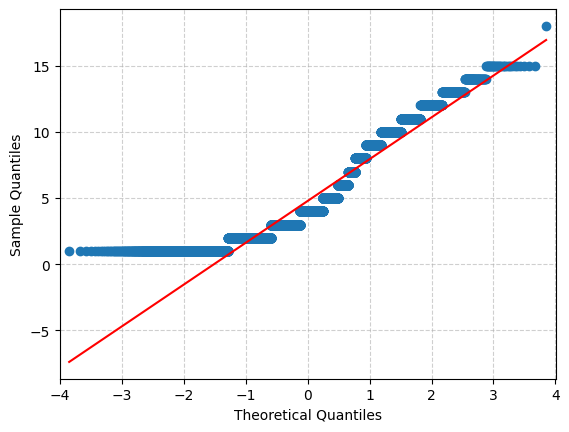

In [ ]:
fig = sm.qqplot(s_an_e_per_post['Unique_PII_Count'],
                line='s')  # line='s'add a standardized line



plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

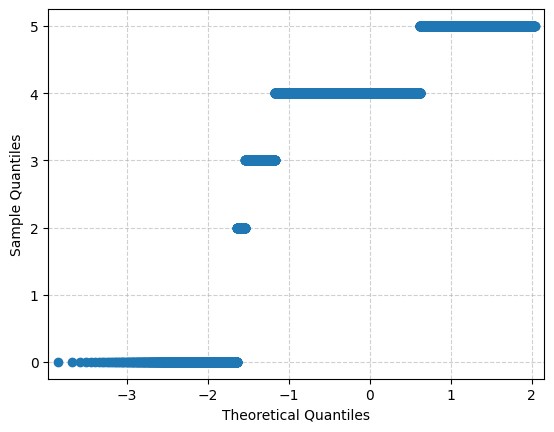

In [ ]:
fig = sm.qqplot(s_an_e_per_post['Severity_Score'],
                line='s')  # line='s' מוסיף קו סטנדרטי (standardized line)



plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

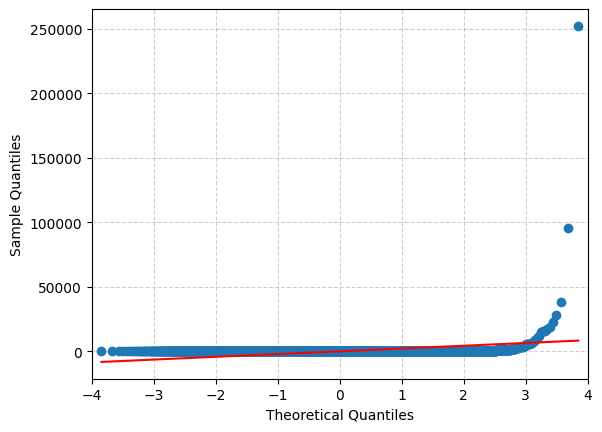

In [ ]:
fig = sm.qqplot(s_an_e_per_post['Exposure_Score'],
                line='s')  # line='s' מוסיף קו סטנדרטי (standardized line)



plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Comparing distributions

Comparing distributions of each exposure severity by average exposure

In [ ]:
print("Number of posts in the tabel: ", len(s_an_e_per_post))
s_an_e_per_post

Number of posts in the tabel:  16941


,Original_DataFrame_Index,Exposure_Score,Severity_Score,Unique_PII_Count
0,3,427.500000,5.0,8
1,4,196.500000,5.0,8
2,5,9.500000,0.0,3
3,7,164.333333,5.0,7
4,9,357.666667,5.0,7
...,...,...,...,...
16936,27234,1.666667,0.0,1
16937,27235,1.000000,2.0,1
16938,27236,1.666667,4.0,5
16939,27237,0.833333,4.0,5


In [ ]:
s_an_e_per_post.describe()

,Original_DataFrame_Index,Exposure_Score,Severity_Score,Unique_PII_Count
count,16941.000000,16941.000000,16588.000000,16941.000000
mean,13675.133935,53.242853,3.960875,4.779765
std,8589.969743,2144.894074,1.090348,3.157732
min,3.000000,0.000000,0.000000,1.000000
25%,5006.000000,0.166667,4.000000,2.000000
50%,14590.000000,0.833333,4.000000,4.000000
75%,21258.000000,3.666667,5.000000,7.000000
max,27238.000000,252252.666667,5.000000,18.000000


In [ ]:
# histogram of Severity_Score = 0:

Severity_Score_0 = s_an_e_per_post[s_an_e_per_post['Severity_Score'] == 0]
Severity_Score_0

,Original_DataFrame_Index,Exposure_Score,Severity_Score,Unique_PII_Count
2,5,9.500000,0.0,3
14,20,3.500000,0.0,1
21,31,36.500000,0.0,1
31,43,1.666667,0.0,1
32,44,2.333333,0.0,1
...,...,...,...,...
16890,27183,80.833333,0.0,2
16904,27199,214.666667,0.0,1
16909,27204,104.333333,0.0,2
16925,27222,21.500000,0.0,1


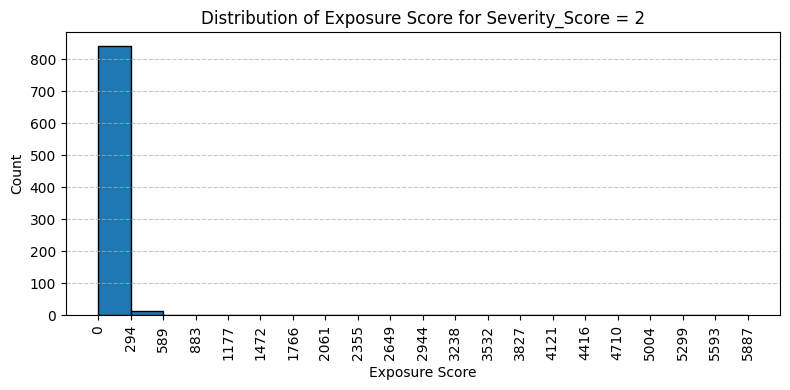

In [ ]:
plt.figure(figsize=(8, 4))
n, bins, patches = plt.hist(Severity_Score_0['Exposure_Score'], bins=20, edgecolor='black')
plt.ylabel("Count")
plt.xlabel("Exposure Score")
plt.title("Distribution of Exposure Score for Severity_Score = 2")

# Set x-axis ticks to the bin edges and rotate them for readability
plt.xticks(bins, rotation=90)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# histogram of Severity_Score = 1:

Severity_Score_1 = s_an_e_per_post[s_an_e_per_post['Severity_Score'] == 1]
Severity_Score_1

,Original_DataFrame_Index,Exposure_Score,Severity_Score,Unique_PII_Count


In [ ]:
# histogram of Severity_Score = 2:

Severity_Score_2 = s_an_e_per_post[s_an_e_per_post['Severity_Score'] == 2]
Severity_Score_2.sample(5)

,Original_DataFrame_Index,Exposure_Score,Severity_Score,Unique_PII_Count
3568,4206,0.333333,2.0,3
14177,24091,7.333333,2.0,1
1764,2254,1.000000,2.0,2
15077,25163,0.166667,2.0,1
14360,24294,8.333333,2.0,2


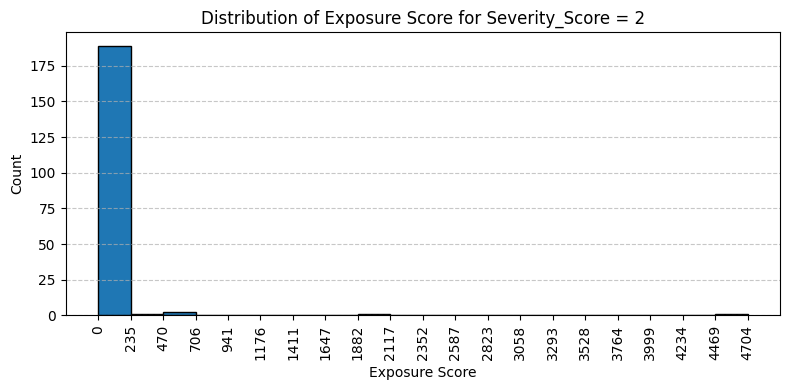

In [ ]:
plt.figure(figsize=(8, 4))
n, bins, patches = plt.hist(Severity_Score_2['Exposure_Score'], bins=20, edgecolor='black')
plt.ylabel("Count")
plt.xlabel("Exposure Score")
plt.title("Distribution of Exposure Score for Severity_Score = 2")

# Set x-axis ticks to the bin edges and rotate them for readability
plt.xticks(bins, rotation=90)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# histogram of Severity_Score = 3:

Severity_Score_3 = s_an_e_per_post[s_an_e_per_post['Severity_Score'] == 3]

Severity_Score_3.sample(5)

,Original_DataFrame_Index,Exposure_Score,Severity_Score,Unique_PII_Count
1896,2410,16.833333,3.0,6
15063,25138,0.166667,3.0,1
16545,26820,6.833333,3.0,2
8858,15035,0.833333,3.0,4
5994,8359,0.000000,3.0,1


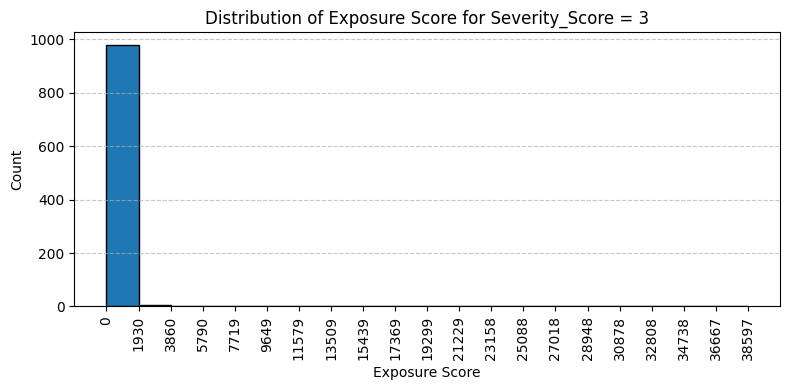

In [ ]:
# Severity_Score_3['Exposure_Score'].hist(bins=50)
# plt.ylabel("count")
# plt.show()

plt.figure(figsize=(8, 4))
n, bins, patches = plt.hist(Severity_Score_3['Exposure_Score'], bins=20, edgecolor='black')
plt.ylabel("Count")
plt.xlabel("Exposure Score")
plt.title("Distribution of Exposure Score for Severity_Score = 3")

# Set x-axis ticks to the bin edges and rotate them for readability
plt.xticks(bins, rotation=90)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# histogram of Severity_Score = 4:

Severity_Score_4 = s_an_e_per_post[s_an_e_per_post['Severity_Score'] == 4]
Severity_Score_4.sample(5)

,Original_DataFrame_Index,Exposure_Score,Severity_Score,Unique_PII_Count
2173,2698,3.666667,4.0,2
5771,7914,0.000000,4.0,3
5852,8105,1.500000,4.0,4
16066,26301,3.166667,4.0,4
6406,9476,0.000000,4.0,7


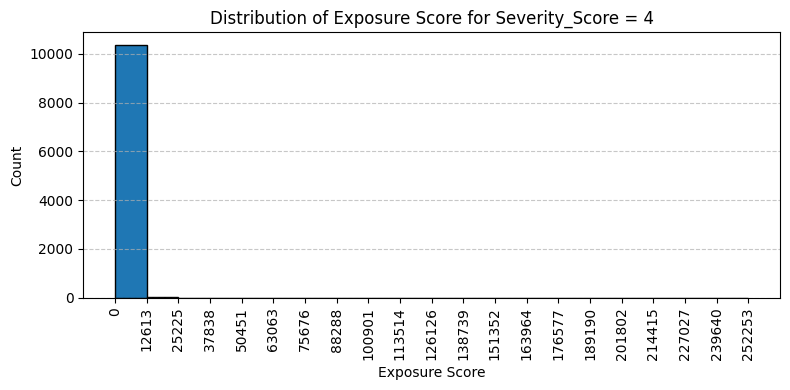

In [ ]:
# Severity_Score_4['Exposure_Score'].hist(bins=50)
# plt.ylabel("count")
# plt.show()

plt.figure(figsize=(8, 4))
n, bins, patches = plt.hist(Severity_Score_4['Exposure_Score'], bins=20, edgecolor='black')
plt.ylabel("Count")
plt.xlabel("Exposure Score")
plt.title("Distribution of Exposure Score for Severity_Score = 4")

# Set x-axis ticks to the bin edges and rotate them for readability
plt.xticks(bins, rotation=90)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# histogram of Severity_Score = 5:

Severity_Score_5 = s_an_e_per_post[s_an_e_per_post['Severity_Score'] == 5]
Severity_Score_5.sample(5)

,Original_DataFrame_Index,Exposure_Score,Severity_Score,Unique_PII_Count
11615,19433,0.000000,5.0,12
9036,15214,0.000000,5.0,5
11730,19568,0.000000,5.0,12
320,402,0.000000,5.0,9
6662,9892,0.333333,5.0,3


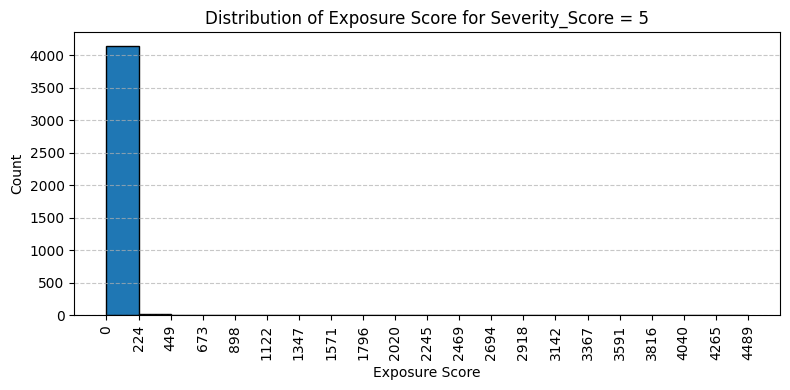

In [ ]:
plt.figure(figsize=(8, 4))
n, bins, patches = plt.hist(Severity_Score_5['Exposure_Score'], bins=20, edgecolor='black')
plt.ylabel("Count")
plt.xlabel("Exposure Score")
plt.title("Distribution of Exposure Score for Severity_Score = 5")

# Set x-axis ticks to the bin edges and rotate them for readability
plt.xticks(bins, rotation=90)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##---------------------------------------------------------------------------

### Kruskal-Wallis H Test

The Kruskal-Wallis H Test 📊What it is:

The Kruskal-Wallis H test is a non-parametric statistical test (By non-parametric we mean, the data is not assumed to become from a particular distribution.) used to compare two or more independent groups. It serves as the non-parametric alternative to One-Way ANOVA when the data is not normally distributed.What it tests:

The test examines whether the medians (or, more precisely, the distribution of ranks) of the different groups are the same.Null Hypothesis ($H_0$): The median of all groups is equal (the populations are identical).Alternative Hypothesis ($H_1$): At least one group has a different median/distribution than the others.When to use it:When the dependent variable is continuous or ordinal (like yours: exposure average).When the independent variable is categorical and defines groups (like yours: severity levels 1, 2, 3...).When normality of the data cannot be assumed (there are outliers, a skewed distribution, etc.).

https://www.geeksforgeeks.org/python/how-to-perform-a-kruskal-wallis-test-in-python/

In [ ]:
result = stats.kruskal(Severity_Score_0['Exposure_Score'], Severity_Score_2['Exposure_Score'], Severity_Score_3['Exposure_Score'], \
                       Severity_Score_4['Exposure_Score'], Severity_Score_5['Exposure_Score'])
result
print("Statistic: ", result.statistic)
print("P-value: ", result.pvalue)
if result.pvalue > 0.05:
  print("As the p-value is not less than 0.05, we cannot reject the null hypothesis that the median mileage of cars is the same for all three groups")
else:
  print("Reject the null hypothesis")

Statistic:  896.7435322156836
P-value:  8.457108852745959e-193
Reject the null hypothesis


In [ ]:
import scikit_posthocs as sp

# Prepare data for Dunn's test by concatenating the Exposure_Score for each group
# and adding a 'Group' column to identify the severity score category.

df0 = Severity_Score_0[['Exposure_Score']].copy()
df0['Group'] = 'Severity_Score_0'

df2 = Severity_Score_2[['Exposure_Score']].copy()
df2['Group'] = 'Severity_Score_2'

df3 = Severity_Score_3[['Exposure_Score']].copy()
df3['Group'] = 'Severity_Score_3'

df4 = Severity_Score_4[['Exposure_Score']].copy()
df4['Group'] = 'Severity_Score_4'

df5 = Severity_Score_5[['Exposure_Score']].copy()
df5['Group'] = 'Severity_Score_5'

# Concatenate all dataframes into a single one
combined_df = pd.concat([df0, df2, df3, df4, df5])

# Perform Dunn's post-hoc test
# We specify 'Exposure_Score' as the value column and 'Group' as the grouping column.
dunn_results = sp.posthoc_dunn(
    combined_df,
    val_col='Exposure_Score',
    group_col='Group',
    p_adjust='bonferroni'
)

print("\n--- תוצאות מבחן דאן (p-values מתוקנים) ---")
print(dunn_results)


--- תוצאות מבחן דאן (p-values מתוקנים) ---
                  Severity_Score_0  Severity_Score_2  Severity_Score_3  \
Severity_Score_0      1.000000e+00      1.000000e+00      1.000000e+00   
Severity_Score_2      1.000000e+00      1.000000e+00      6.170798e-01   
Severity_Score_3      1.000000e+00      6.170798e-01      1.000000e+00   
Severity_Score_4      8.652459e-40      1.174187e-13      3.599623e-34   
Severity_Score_5     1.128877e-104      1.153648e-33     7.480444e-100   

                  Severity_Score_4  Severity_Score_5  
Severity_Score_0      8.652459e-40     1.128877e-104  
Severity_Score_2      1.174187e-13      1.153648e-33  
Severity_Score_3      3.599623e-34     7.480444e-100  
Severity_Score_4      1.000000e+00      5.653910e-77  
Severity_Score_5      5.653910e-77      1.000000e+00  


# ------------------------------------------------------------------------

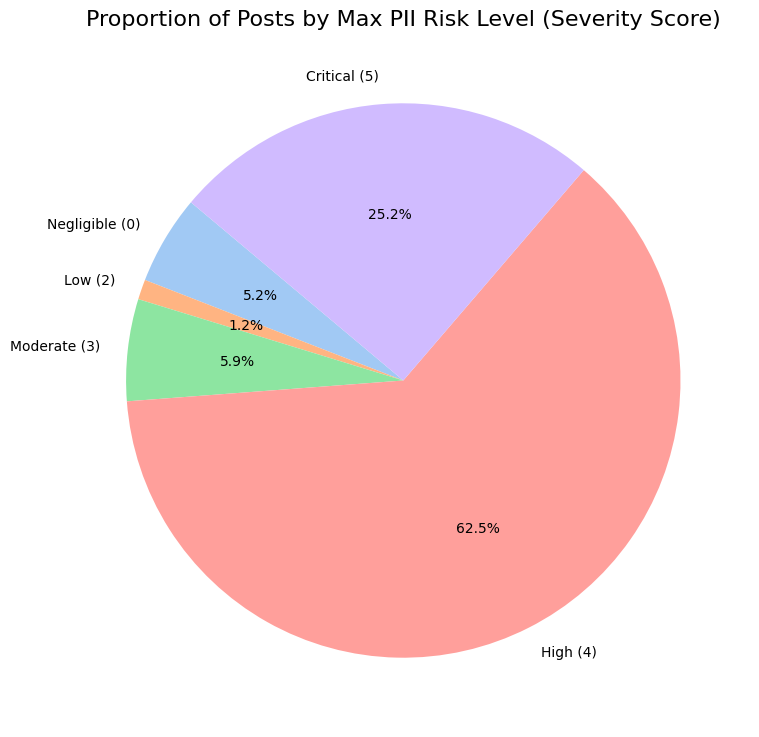

In [ ]:
# Count the number of posts for each Severity Score
severity_counts = s_an_e_per_post['Severity_Score'].value_counts().sort_index()

# Define descriptive labels for the severity scores
labels_map = {
    5: 'Critical (5)',
    4: 'High (4)',
    3: 'Moderate (3)',
    2: 'Low (2)',
    0: 'Negligible (0)'
}

# Create labels list matching the index of severity_counts
labels = [labels_map.get(x, str(x)) for x in severity_counts.index]

# Create the Pie Chart
plt.figure(figsize=(9, 9))
plt.pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proportion of Posts by Max PII Risk Level (Severity Score)', fontsize=16)
plt.show()

# =================================================================================

# **TabStar**

## **Data preparation**


In [ ]:
inf_df.head(3)

,Original_DataFrame_Index,Original_Text,PII_Entity,PII_Type,Score,Source,Exposure_Score
0,0,***Update**** - Only one spot remains Due to ...,None,None,NaN,None,7.833333
1,1,More info than Wikipedia... and with fewer don...,None,None,NaN,None,5.166667
2,2,This blood donation app connects donors and re...,None,None,NaN,None,4.500000


In [ ]:
# קיבוץ הנתונים לפי אינדקס הפוסט המקורי
tabstar_df = pii_df.groupby('Original_DataFrame_Index').agg({
    'Original_Text': 'first',      # לוקחים את הטקסט (הוא זהה לכל השורות של אותו אינדקס)
    'Exposure_Score': 'first',     # לוקחים את ציון החשיפה
    'PII_Entity': lambda x: x.notna().any() # יוצר עמודה של True אם נמצא PII כלשהו, ו-False אם לא
}).reset_index()

# שינוי שמות העמודות כדי שיהיו ברורות למודל
tabstar_df.rename(columns={'PII_Entity': 'Label_Has_PII'}, inplace=True)

# המרת ה-Label למספרים (1 ל-יש PII, 0 ל-אין PII) לצורך הקלסיפיקציה
tabstar_df['Label_Has_PII'] = tabstar_df['Label_Has_PII'].astype(int)

# הצגת התוצאה
print(f"טבלת ה-TabSTAR מוכנה. מספר שורות (פוסטים): {len(tabstar_df)}")
display(tabstar_df.head())

טבלת ה-TabSTAR מוכנה. מספר שורות (פוסטים): 18290


,Original_DataFrame_Index,Original_Text,Exposure_Score,Label_Has_PII
0,0,***Update**** - Only one spot remains Due to ...,7.833333,0
1,1,More info than Wikipedia... and with fewer don...,5.166667,0
2,2,This blood donation app connects donors and re...,4.500000,0
3,3,(Sofar 35k sent to her) We received this donat...,427.500000,1
4,4,(Sofar 5k recd & sent to her) We received this...,196.500000,1


## **Model**

In [ ]:
from huggingface_hub import snapshot_download

# הורדה ידנית של המודל לדיסק המקומי ב-Colab
# זה יעקוף את הבעיה של local_files_only=True
print("Downloading model files to local cache...")
snapshot_download(repo_id="alana89/TabSTAR")
print("Done! Now you can run TabSTAR.")

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Done! Now you can run TabSTAR.


In [ ]:
from sklearn.model_selection import train_test_split
from tabstar.tabstar_model import TabSTARClassifier, TabSTARRegressor
from sklearn.metrics import classification_report

# --- הכנת הנתונים (שימוש ב-tabstar_df שיצרנו קודם) ---

# תיקון בחירת העמודות (רשימה בתוך סוגריים מרובעים)
X = tabstar_df[['Original_Text', 'Exposure_Score']]
y = tabstar_df['Label_Has_PII']

is_cls = True

# פיצול נתונים ל-Train ו-Test (חשוב מאוד ל-Benchmark אמין)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- הגדרת המודל עם אופטימיזציה למהירות ---

tabstar_cls = TabSTARClassifier if is_cls else TabSTARRegressor

# הגדרות לריצה מהירה על 10K+ דוגמאות:
tabstar = tabstar_cls(
    device=device,
    max_epochs=10,              # הגבלה ל-10 סבבים במקום 50
)

# --- אימון ---
print(f"Starting TabSTAR training on {len(x_train)} samples...")
tabstar.fit(x_train, y_train)

# --- חיזוי והערכה ---
y_pred = tabstar.predict(x_test)

print("\n--- TabSTAR Execution Complete ---")
print(f"Model score on test set: {tabstar.score(X=x_test, y=y_test)}")

# הדפסת דוח ביצועים מפורט (Precision/Recall)
if is_cls:
    print("\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred))

🖥️ Using device: cuda
Starting TabSTAR training on 14632 samples...
🤩 Loading pretrained model version: alana89/TabSTAR


RuntimeError: You are using `from_pretrained` with a meta device context manager or `torch.set_default_device('meta')`.
This is an anti-pattern as `from_pretrained` wants to load existing weights.
If you want to initialize an empty model on the meta device, use the context manager or global device with `from_config`, or `ModelClass(config)`